### Bereinigung der Transkripte

In [6]:
import json
import re

input_path = "last_llm_transcripts.json"
output_path = "last_clean_llm_transcripts.json"

with open(input_path, "r", encoding="utf-8") as infile, open(output_path, "w", encoding="utf-8") as outfile:
    for line in infile:
        if not line.strip():
            continue

        data = json.loads(line)
        text = data.get("text", "")

        # 1️⃣ Alles löschen, was vor "Transcript starts here:" steht
        #    re.S = '.' matcht über mehrere Zeilen
        #    re.I = Case-insensitive
        text = re.sub(
            r".*?Transcript starts here:\s*",
            "",
            text,
            flags=re.I | re.S
        )

        # 2️⃣ Echte Zeilenumbrüche entfernen
        text = re.sub(r"\s*\n+\s*", " ", text)

        # 3️⃣ Escaped "\n" entfernen
        text = text.replace("\\n", " ")

        # 4️⃣ Whitespace bereinigen
        text = text.strip()

        # 5️⃣ Text zurück ins JSON-Objekt
        data["text"] = text

        # 6️⃣ Saubere Zeile schreiben
        outfile.write(json.dumps(data, ensure_ascii=False) + "\n")


## Einlesen in df

In [ ]:
import pandas as pd
# --- 1️⃣ Daten einlesen ---
df = pd.read_json("last_clean_llm_transcripts.json", lines=True)

In [8]:
df

,experiment_id,audio_id,type,tags,text
0,1760,Anam_Rueckenschmerzen,output,"[AI, STT, Transcript, HighQuality]","Schönen guten Tag, mein Name ist Nina Colette ..."
1,1737,Anam_Fahrradunfall_01,output,"[AI, STT, Transcript]","Guten Tag, grüß dich, mein Name ist Christian ..."
2,1971,Anam_Fremdanamnese_Saeugling,output,"[AI, STT, Transcript]","Schönen guten Tag, Nina Colette ist mein Name...."
3,1973,Anam_Oesophaguskarzinom,output,"[AI, STT, Transcript]",Schönen guten Morgen. Nina Kulett ist mein Nam...
4,1975,Anam_Venenthrombose_TVT,output,"[AI, STT, Transcript]","Schönen guten Tag, mein Name ist Nina Colette ..."
5,1974,Anam_Traumaanamnese,output,"[AI, STT, Transcript]",Schönen guten Tag. Colette ist mein Name. Ich ...
6,1972,Anam_Lymphom,output,"[AI, STT, Transcript]","Guten Tag, Kulett ist mein Name. Ich werde jet..."
7,1970,Anam_Fremdanamnese,output,"[AI, STT, Transcript]","Schönen guten Tag zusammen, Nina Colette ist m..."
8,1969,Anam_Appendizitis,output,"[AI, STT, Transcript]","Schönen guten Tag, bitte nehmen Sie Platz. Gut..."
9,1950,Anam_sexueller_Missbrauch,output,"[AI, STT, Transcript]","Schönen guten Tag, Nina Kulett ist mein Name, ..."


## Wieviel Tokens hat jede Transkript ? 

In [10]:
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import pandas as pd


# ============================================================
# 2. Tokenizer holen (Jina v3)
# ============================================================
st_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3",
    trust_remote_code=True
)
tokenizer = st_model[0].tokenizer

# ============================================================
# 3. Neues DataFrame vorbereiten
# ============================================================
new_rows = []   # Hier speichern wir die Ergebnisse

# ============================================================
# 4. Token-Anzahl pro Text berechnen
# ============================================================
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Token zählen"):
    text = row["text"] if pd.notna(row["text"]) else ""

    # Tokenisieren (ungeschnitten, für echte Anzahl)
    tokens = tokenizer(
        text,
        return_tensors="pt",
        truncation=False,
        add_special_tokens=True
    )
    token_count = tokens["input_ids"].shape[1]

    new_rows.append({
        "audio_id": row["audio_id"],
       
  
        "token_count": token_count,
        "char_length": len(text),
        "text_preview": text[:300]  # optional: kurze Vorschau
    })

# ============================================================
# 5. Neues DataFrame erstellen
# ============================================================
token_df = pd.DataFrame(new_rows)

# ============================================================
# 6. Erste Zeilen ansehen
# ============================================================
print(token_df.head())


flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

                       audio_id  token_count  char_length  \
0         Anam_Rueckenschmerzen         2184         8995   
1         Anam_Fahrradunfall_01         3691        15071   
2  Anam_Fremdanamnese_Saeugling         3627        14754   
3       Anam_Oesophaguskarzinom         4502        18556   
4       Anam_Venenthrombose_TVT         3782        15519   

                                        text_preview  
0  Schönen guten Tag, mein Name ist Nina Colette ...  
1  Guten Tag, grüß dich, mein Name ist Christian ...  
2  Schönen guten Tag, Nina Colette ist mein Name....  
3  Schönen guten Morgen. Nina Kulett ist mein Nam...  
4  Schönen guten Tag, mein Name ist Nina Colette ...  


In [12]:
token_df[token_df["token_count"] > 4000]


,audio_id,token_count,char_length,text_preview
3,Anam_Oesophaguskarzinom,4502,18556,Schönen guten Morgen. Nina Kulett ist mein Nam...
23,Anam_Aengstliche-Patientin,4693,20021,"Schönen guten Tag, mein Name ist Nina Kulek. I..."


### Okay, wir haben also maximal 4693 Tokens. Die Embeddingsmodelle mit über 8000 sind gut geeignet.

### Embedding mit Llama

In [15]:
## Für die Nutzung des Modells Llama

from openai import OpenAI

client = OpenAI(base_url="http://localhost:8002/v1", api_key="none")



In [16]:
import pandas as pd
from openai import OpenAI
import numpy as np
from tqdm import tqdm  # Fortschrittsanzeige


# --- 3️⃣ Neue Spalte vorbereiten ---
col_name = "embedding_Llama-3.1_8B-Instruct"
df[col_name] = None

# --- 4️⃣ Embeddings erzeugen (Batchweise optional) ---
embeddings = []

for text in tqdm(df["text"], desc="Berechne Embeddings"):
    if not isinstance(text, str) or not text.strip():
        embeddings.append(None)
        continue
    
    response = client.embeddings.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        input=text
    )
    emb = response.data[0].embedding
    embeddings.append(emb)

df[col_name] = embeddings

# --- 5️⃣ Datei speichern ---
df.to_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

print(f"✅ Fertig! {len(df)} Texte mit Spalte '{col_name}' gespeichert.")


Berechne Embeddings: 100%|██████████| 26/26 [03:43<00:00,  8.61s/it]

✅ Fertig! 26 Texte mit Spalte 'embedding_Llama-3.1_8B-Instruct' gespeichert.


In [19]:
import pandas as pd

df = pd.read_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

df.head()



,experiment_id,audio_id,type,tags,text,embedding_Llama-3.1_8B-Instruct
0,1760,Anam_Rueckenschmerzen,output,"[AI, STT, Transcript, HighQuality]","Schönen guten Tag, mein Name ist Nina Colette ...","[0.002029490889981389, -0.005923919379711151, ..."
1,1737,Anam_Fahrradunfall_01,output,"[AI, STT, Transcript]","Guten Tag, grüß dich, mein Name ist Christian ...","[-0.008539176546037197, -0.010412286035716534,..."
2,1971,Anam_Fremdanamnese_Saeugling,output,"[AI, STT, Transcript]","Schönen guten Tag, Nina Colette ist mein Name....","[0.004057756159454584, -0.0007197033846750855,..."
3,1973,Anam_Oesophaguskarzinom,output,"[AI, STT, Transcript]",Schönen guten Morgen. Nina Kulett ist mein Nam...,"[0.0040346127934753895, 0.0023466625716537237,..."
4,1975,Anam_Venenthrombose_TVT,output,"[AI, STT, Transcript]","Schönen guten Tag, mein Name ist Nina Colette ...","[0.00039932437357492745, -0.006087554153054953..."


## Embedding mit einem anderen Modell jina-embeddings-v3

In [20]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

# --- 1️⃣ DataFrame laden ---
df = pd.read_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

# --- 2️⃣ Modell laden ---
model = SentenceTransformer(
    "jinaai/jina-embeddings-v3",
    trust_remote_code=True,
    device="cuda"
)


flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

In [21]:
# --- 3️⃣ Neue Spalte definieren ---
col_name = "embedding_Jina_v3"
df[col_name] = None

# --- 4️⃣ Embeddings berechnen ---
texts = df["text"].fillna("").tolist()
embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=2,         # effizienter auf GPU (mit 20, 10 oder sogar 5 kam eine Fehlermeldung!)
    normalize_embeddings=True #(das habe ich vorher nicht gemaht. Es kann aber wichtig sein!)
)

# --- 5️⃣ Embeddings in DataFrame speichern ---
df[col_name] = embeddings.tolist()

# --- 6️⃣ Wieder speichern ---
df.to_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

print(f"✅ {len(df)} Embeddings mit JinaAI v3 berechnet und in '{col_name}' gespeichert.")

Batches: 100%|██████████| 13/13 [00:02<00:00,  5.14it/s]


✅ 26 Embeddings mit JinaAI v3 berechnet und in 'embedding_Jina_v3' gespeichert.


## Embedding mit einem anderen Modell aari1995/German_Semantic_V3b 

In [22]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm


# --- 1️⃣ DataFrame laden ---
df = pd.read_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

# --- 2️⃣ Modell laden ---
model = SentenceTransformer(
    "aari1995/German_Semantic_V3b",
    trust_remote_code=True,
    device="cpu" 
)

In [23]:
# --- 3️⃣ Neue Spalte definieren ---
col_name = "aari1995/German_Semantic_V3b"
df[col_name] = None

# --- 4️⃣ Embeddings berechnen ---
texts = df["text"].fillna("").tolist()
embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=1,         # effizienter auf GPU (mit 20, 10 oder sogar 5 kam eine Fehlermeldung!)
    normalize_embeddings=True, #(das habe ich vorher nicht gemaht. Es kann aber wichtig sein!)
    #output_value="sentence_embedding_128"
)

# --- 5️⃣ Embeddings in DataFrame speichern ---
df[col_name] = embeddings.tolist()

# --- 6️⃣ Wieder speichern ---
df.to_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

print(f"✅ {len(df)} Embeddings mit aari1995/German_Semantic_V3b berechnet und in '{col_name}' gespeichert.")

Batches: 100%|██████████| 26/26 [03:45<00:00,  8.69s/it]

✅ 26 Embeddings mit aari1995/German_Semantic_V3b berechnet und in 'aari1995/German_Semantic_V3b' gespeichert.


# BAAI/bge-m3

In [24]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm


# --- 1️⃣ DataFrame laden ---
df = pd.read_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

# --- 2️⃣ Modell laden ---
model = SentenceTransformer(
    "BAAI/bge-m3",
    trust_remote_code=True,
    device="cuda" #bei cuda hat es nicht geklappt CUDA out of memory
)

In [25]:
# --- 3️⃣ Neue Spalte definieren ---
col_name = "BAAI/bge-m3"
df[col_name] = None

# --- 4️⃣ Embeddings berechnen ---
texts = df["text"].fillna("").tolist()
embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=1,         # effizienter auf GPU (mit 20, 10 oder sogar 5 kam eine Fehlermeldung!)
    normalize_embeddings=True, #(das habe ich vorher nicht gemaht. Es kann aber wichtig sein!)
)

# --- 5️⃣ Embeddings in DataFrame speichern ---
df[col_name] = embeddings.tolist()

# --- 6️⃣ Wieder speichern ---
df.to_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

print(f"✅ {len(df)} Embeddings mit BAAI/bge-m3 berechnet und in '{col_name}' gespeichert.")

Batches: 100%|██████████| 26/26 [00:03<00:00,  7.57it/s]


✅ 26 Embeddings mit BAAI/bge-m3 berechnet und in 'BAAI/bge-m3' gespeichert.


# Alibaba-NLP/gte-multilingual-base

In [26]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm


# --- 1️⃣ DataFrame laden ---
df = pd.read_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

# --- 2️⃣ Modell laden ---
model = SentenceTransformer(
    "Alibaba-NLP/gte-multilingual-base",
    trust_remote_code=True,
    device="cuda" #bei cuda hat es nicht geklappt CUDA out of memory
 
)

Some weights of the model checkpoint at Alibaba-NLP/gte-multilingual-base were not used when initializing NewModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing NewModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing NewModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
# --- 3️⃣ Neue Spalte definieren ---
col_name = "Alibaba-NLP/gte-multilingual-base"
df[col_name] = None

# --- 4️⃣ Embeddings berechnen ---
texts = df["text"].fillna("").tolist()
embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=1,         # effizienter auf GPU (mit 20, 10 oder sogar 5 kam eine Fehlermeldung!)
    normalize_embeddings=True, #(das habe ich vorher nicht gemaht. Es kann aber wichtig sein!)
)

# --- 5️⃣ Embeddings in DataFrame speichern ---
df[col_name] = embeddings.tolist()

# --- 6️⃣ Wieder speichern ---
df.to_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

print(f"✅ {len(df)} Embeddings mit Alibaba-NLP/gte-multilingual-base berechnet und in '{col_name}' gespeichert.")

Batches: 100%|██████████| 26/26 [00:01<00:00, 17.15it/s]

✅ 26 Embeddings mit Alibaba-NLP/gte-multilingual-base berechnet und in 'Alibaba-NLP/gte-multilingual-base' gespeichert.


In [3]:
import pandas as pd

# --- 1️⃣ DataFrame laden ---
df1 = pd.read_parquet("last_clean_llm_experiments_with_embeddings.parquet")

# --- 1️⃣ DataFrame laden ---
df2 = pd.read_parquet("last_clean_llm_transcripts_with_embeddings.parquet")

In [4]:
df1.head(2)

,experiment_id,audio_id,model_name,run_id,type,tags,text,embedding_Llama-3.1_8B-Instruct,embedding_Jina_v3,BAAI/bge-m3,Alibaba-NLP/gte-multilingual-base,aari1995/German_Semantic_V3b,token_embeddings_jina_v3
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,P1_01_03,output,"[AI, LLM, STT, Summary, Llama 3.1 SauerkrautLM...","Patient: Frau Mayerhose, 55 Jahre alt, geboren...","[-0.0008558990084566176, -0.020405177026987076...","[0.05810546875, -0.08203125, 0.0225830078125, ...","[0.06356414407491684, -0.01877567172050476, -0...","[-0.05058562010526657, 0.10307077318429947, -0...","[0.046458642929792404, -0.017108825966715813, ...","[[1.140625, -1.3359375, 0.232421875, 1.890625,..."
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,P1_01_01,output,"[AI, LLM, STT, Summary, Llama 3.1 SauerkrautLM...","Patient: Frau Mayerhose Katarina, 55 Jahre alt...","[-0.001057965331710875, -0.01998530514538288, ...","[0.06689453125, -0.11328125, 0.002471923828125...","[0.05369797721505165, -0.006991442758589983, -...","[-0.05944622680544853, 0.1052369698882103, 0.0...","[0.059302035719156265, -0.02372737042605877, 0...","[[1.2265625, -1.8046875, -0.043212890625, 1.84..."


In [5]:
df2.head(2)

,experiment_id,audio_id,type,tags,text,embedding_Llama-3.1_8B-Instruct,embedding_Jina_v3,aari1995/German_Semantic_V3b,BAAI/bge-m3,Alibaba-NLP/gte-multilingual-base
0,1760,Anam_Rueckenschmerzen,output,"[AI, STT, Transcript, HighQuality]","Schönen guten Tag, mein Name ist Nina Colette ...","[0.002029490889981389, -0.005923919379711151, ...","[0.0223388671875, -0.1337890625, 0.0478515625,...","[0.06959879398345947, 0.008214921690523624, 0....","[0.021290503442287445, 0.008265030570328236, -...","[-0.08962889015674591, 0.031790755689144135, -..."
1,1737,Anam_Fahrradunfall_01,output,"[AI, STT, Transcript]","Guten Tag, grüß dich, mein Name ist Christian ...","[-0.008539176546037197, -0.010412286035716534,...","[0.0361328125, -0.10888671875, -0.005645751953...","[0.05028754100203514, 0.011676323600113392, 0....","[-0.028482552617788315, 0.03131008893251419, -...","[-0.04778056964278221, 0.040268220007419586, 0..."


### Bis hier haben wir alle Transkripte eingebettet mit allen 5 Embeddingsmodelle. Ab hier sollen diese Trnskripte mit den Zusammenfassungen (experiments) verglichen werden

In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------------------------------
# 1. Hilfsfunktion: Cosine Similarity für zwei Vektoren
# -------------------------------------------------------
def cos_sim(vec1, vec2):
    if vec1 is None or vec2 is None:
        return np.nan
    v1 = np.array(vec1).reshape(1, -1)
    v2 = np.array(vec2).reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])


# -------------------------------------------------------
# 2. Liste der Embedding-Spalten definieren
# -------------------------------------------------------
embedding_cols = [
    "embedding_Llama-3.1_8B-Instruct",
    "embedding_Jina_v3",
    "BAAI/bge-m3",
    "Alibaba-NLP/gte-multilingual-base",
    "aari1995/German_Semantic_V3b"
]


# -------------------------------------------------------
# 3. Join df1 ↔ df2 über audio_id
#     (df2 = STT, df1 = LLM-Outputs)
# -------------------------------------------------------
df_join = df1.merge(
    df2[["audio_id"] + embedding_cols],
    on="audio_id",
    suffixes=("_df1", "_df2")
)


# -------------------------------------------------------
# 4. Similaritywerte berechnen
#    Für jedes Embeddingmodell separat
# -------------------------------------------------------
for emb in embedding_cols:
    df_join[f"sim_{emb}"] = df_join.apply(
        lambda row: cos_sim(row[f"{emb}_df1"], row[f"{emb}_df2"]),
        axis=1
    )


# -------------------------------------------------------
# 5. Aggregation:
#    pro LLM-Modell (model_name) über ALLE audio_ids & Wiederholungen
# -------------------------------------------------------
results = {}

for emb in embedding_cols:
    sim_col = f"sim_{emb}"
    
    summary = (
        df_join
        .groupby("model_name")[sim_col]
        .agg(['mean', 'std', 'min', 'max', 'count'])
        .reset_index()
    )
    
    results[emb] = summary


# -------------------------------------------------------
# 6. Optional: Alle embedding-Result-Tables kombinieren
# -------------------------------------------------------
final_scores = pd.DataFrame({"model_name": df_join["model_name"].unique()})

for emb in embedding_cols:
    final_scores = final_scores.merge(
        results[emb][["model_name", "mean"]].rename(columns={"mean": f"score_{emb}"}),
        on="model_name",
        how="left"
    )

# final_scores enthält:
# pro LLM-Modell je einen Score für jedes Embeddingmodell
final_scores


,model_name,score_embedding_Llama-3.1_8B-Instruct,score_embedding_Jina_v3,score_BAAI/bge-m3,score_Alibaba-NLP/gte-multilingual-base,score_aari1995/German_Semantic_V3b
0,Llama 3.1 SauerkrautLM 70B Instruct,0.673287,0.799833,0.769068,0.817691,0.923617
1,MedGemma 27B Instruct,0.634648,0.825300,0.838681,0.838942,0.958984
2,Meta Llama 3.1 8B Instruct,0.691813,0.830129,0.805668,0.825440,0.925447
3,OpenAI GPT OSS 120B,0.661290,0.831045,0.853286,0.836942,0.960181
4,OpenAI GPT-5,0.668796,0.811049,0.834982,0.829342,0.960674
5,GPT-5,0.632764,0.784629,0.803206,0.820003,0.948727


In [7]:
# Alle Spalten außer model_name ermitteln
score_cols = [c for c in final_scores.columns if c != "model_name"]

sorted_dfs = {}

# Jede Score-Spalte separat sortieren (aufsteigend)
for col in score_cols:
    sorted_dfs[col] = (
        final_scores[["model_name", col]]
        .sort_values(col, ascending=False)
        .reset_index(drop=True)
    )

# Alle sortierten Tabellen nebeneinander zusammenführen
combined = pd.concat(sorted_dfs.values(), axis=1)

combined


,model_name,score_embedding_Llama-3.1_8B-Instruct,model_name,score_embedding_Jina_v3,model_name,score_BAAI/bge-m3,model_name,score_Alibaba-NLP/gte-multilingual-base,model_name,score_aari1995/German_Semantic_V3b
0,Meta Llama 3.1 8B Instruct,0.691813,OpenAI GPT OSS 120B,0.831045,OpenAI GPT OSS 120B,0.853286,MedGemma 27B Instruct,0.838942,OpenAI GPT-5,0.960674
1,Llama 3.1 SauerkrautLM 70B Instruct,0.673287,Meta Llama 3.1 8B Instruct,0.830129,MedGemma 27B Instruct,0.838681,OpenAI GPT OSS 120B,0.836942,OpenAI GPT OSS 120B,0.960181
2,OpenAI GPT-5,0.668796,MedGemma 27B Instruct,0.825300,OpenAI GPT-5,0.834982,OpenAI GPT-5,0.829342,MedGemma 27B Instruct,0.958984
3,OpenAI GPT OSS 120B,0.661290,OpenAI GPT-5,0.811049,Meta Llama 3.1 8B Instruct,0.805668,Meta Llama 3.1 8B Instruct,0.825440,GPT-5,0.948727
4,MedGemma 27B Instruct,0.634648,Llama 3.1 SauerkrautLM 70B Instruct,0.799833,GPT-5,0.803206,GPT-5,0.820003,Meta Llama 3.1 8B Instruct,0.925447
5,GPT-5,0.632764,GPT-5,0.784629,Llama 3.1 SauerkrautLM 70B Instruct,0.769068,Llama 3.1 SauerkrautLM 70B Instruct,0.817691,Llama 3.1 SauerkrautLM 70B Instruct,0.923617


In [52]:
combined

,model_name,score_embedding_Llama-3.1_8B-Instruct,score_embedding_Jina_v3,score_BAAI/bge-m3,score_Alibaba-NLP/gte-multilingual-base,score_aari1995/German_Semantic_V3b
0,Llama 3.1 SauerkrautLM 70B Instruct,0.673287,0.799833,0.769068,0.817691,0.923617
1,Meta Llama 3.1 8B Instruct,0.691813,0.830129,0.805668,0.825440,0.925447
2,GPT-5,0.632764,0.784629,0.803206,0.820003,0.948727
3,MedGemma 27B Instruct,0.634648,0.825300,0.838681,0.838942,0.958984
4,OpenAI GPT OSS 120B,0.661290,0.831045,0.853286,0.836942,0.960181
5,OpenAI GPT-5,0.668796,0.811049,0.834982,0.829342,0.960674


## nochmal gleiche Ausgabe aber auch für jedes embedding getrennt für jede Audio

### vielleicht so können wir gucken ab welchem Embeddingsscore die Zusammenfassung Sinn machen würde ?!

In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------------------------------
# 1. Hilfsfunktion: Cosine Similarity für zwei Vektoren
# -------------------------------------------------------
def cos_sim(vec1, vec2):
    if vec1 is None or vec2 is None:
        return np.nan
    v1 = np.array(vec1).reshape(1, -1)
    v2 = np.array(vec2).reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])


# -------------------------------------------------------
# 2. Liste der Embedding-Spalten definieren
# -------------------------------------------------------
embedding_cols = [
    "embedding_Llama-3.1_8B-Instruct",
    "embedding_Jina_v3",
    "BAAI/bge-m3",
    "Alibaba-NLP/gte-multilingual-base",
    "aari1995/German_Semantic_V3b"
]


# -------------------------------------------------------
# 3. Join df1 ↔ df2 über audio_id (experiment_id übernehmen!)
# -------------------------------------------------------
df_join = df1.merge(
    df2[["audio_id"] + embedding_cols],
    on="audio_id",
    suffixes=("_df1", "_df2")
)

# experiment_id MUSS in df1 vorhanden sein → sonst hier anpassen
if "experiment_id" in df1.columns:
    df_join["experiment_id"] = df1["experiment_id"]
else:
    print("⚠️ WARNUNG: experiment_id wurde nicht gefunden!")


# -------------------------------------------------------
# 4. Similaritywerte berechnen
# -------------------------------------------------------
for emb in embedding_cols:
    df_join[f"sim_{emb}"] = df_join.apply(
        lambda row: cos_sim(row[f"{emb}_df1"], row[f"{emb}_df2"]),
        axis=1
    )


# -------------------------------------------------------
# Similarity-Tabellen erstellen (MIT experiment_id)
# -------------------------------------------------------
similarity_tables = {}

for emb in embedding_cols:
    sim_col = f"sim_{emb}"

    similarity_tables[emb] = df_join[[
        "experiment_id",      # neu
        "audio_id",
        "model_name",
        sim_col
    ]].copy()

    print(f"\n--- Similarity-Tabelle für: {emb} ---")
    display(similarity_tables[emb].head())


# -------------------------------------------------------
# Aggregation pro LLM-Modell
# -------------------------------------------------------
results = {}

for emb in embedding_cols:
    sim_col = f"sim_{emb}"
    
    summary = (
        df_join
        .groupby("model_name")[sim_col]
        .agg(['mean', 'std', 'min', 'max', 'count'])
        .reset_index()
    )
    
    results[emb] = summary


# -------------------------------------------------------
# 6. Finale Übersichtstabelle
# -------------------------------------------------------
final_scores = pd.DataFrame({"model_name": df_join["model_name"].unique()})

for emb in embedding_cols:
    final_scores = final_scores.merge(
        results[emb][["model_name", "mean"]].rename(columns={"mean": f"score_{emb}"}),
        on="model_name",
        how="left"
    )

print("\n===== FINAL SCORES =====")
display(final_scores)


# -------------------------------------------------------
# 7. CSV-Export (jetzt MIT experiment_id)
# -------------------------------------------------------
for emb in embedding_cols:
    df_export = similarity_tables[emb]

    safe_emb = emb.replace("/", "_")  # Dateiname sicher machen
    filename = f"similarity_{safe_emb}.csv"

    df_export.to_csv(filename, index=False, encoding="utf-8")

    print(f"✔ CSV gespeichert: {filename}")



--- Similarity-Tabelle für: embedding_Llama-3.1_8B-Instruct ---


,experiment_id,audio_id,model_name,sim_embedding_Llama-3.1_8B-Instruct
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.707177
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.712814
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,0.358001
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.681064
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,0.587599



--- Similarity-Tabelle für: embedding_Jina_v3 ---


,experiment_id,audio_id,model_name,sim_embedding_Jina_v3
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.819861
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.838030
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,0.828012
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.835934
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,0.845179



--- Similarity-Tabelle für: BAAI/bge-m3 ---


...


--- Similarity-Tabelle für: aari1995/German_Semantic_V3b ---


,experiment_id,audio_id,model_name,sim_aari1995/German_Semantic_V3b
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.918370
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.932747
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,0.901701
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.931881
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,0.976707



===== FINAL SCORES =====


,model_name,score_embedding_Llama-3.1_8B-Instruct,score_embedding_Jina_v3,score_BAAI/bge-m3,score_Alibaba-NLP/gte-multilingual-base,score_aari1995/German_Semantic_V3b
0,Llama 3.1 SauerkrautLM 70B Instruct,0.673287,0.799833,0.769068,0.817691,0.923617
1,MedGemma 27B Instruct,0.634648,0.825300,0.838681,0.838942,0.958984
2,Meta Llama 3.1 8B Instruct,0.691813,0.830129,0.805668,0.825440,0.925447
3,OpenAI GPT OSS 120B,0.661290,0.831045,0.853286,0.836942,0.960181
4,OpenAI GPT-5,0.668796,0.811049,0.834982,0.829342,0.960674
5,GPT-5,0.632764,0.784629,0.803206,0.820003,0.948727


✔ CSV gespeichert: similarity_embedding_Llama-3.1_8B-Instruct.csv
✔ CSV gespeichert: similarity_embedding_Jina_v3.csv
✔ CSV gespeichert: similarity_BAAI_bge-m3.csv
✔ CSV gespeichert: similarity_Alibaba-NLP_gte-multilingual-base.csv
✔ CSV gespeichert: similarity_aari1995_German_Semantic_V3b.csv


# Das mit der Halluzination (added content)
## Added = ||Summary|| / ||Transcript||

In [40]:
import numpy as np
import pandas as pd

# -------------------------------------------------------
# 1. Hilfsfunktion: Norm-Verhältnis
# -------------------------------------------------------
def added_content_score(vec1, vec2):
    """Norm-Verhältnis summary/transcript (Halluzinations-Indikator)."""
    if vec1 is None or vec2 is None:
        return np.nan
    n1 = np.linalg.norm(vec1)
    n2 = np.linalg.norm(vec2)
    if n2 == 0:
        return np.nan
    return float(np.clip(n1 / n2, 0.5, 2.0))   # optional stabilisierung


# -------------------------------------------------------
# 2. Embedding-Spalten
# -------------------------------------------------------
embedding_cols = [
    "embedding_Llama-3.1_8B-Instruct",
    "embedding_Jina_v3",
    "BAAI/bge-m3",
    "Alibaba-NLP/gte-multilingual-base",
    "aari1995/German_Semantic_V3b"
]


# -------------------------------------------------------
# 3. Join df1 ↔ df2 über audio_id
# -------------------------------------------------------
df_join = df1.merge(
    df2[["audio_id"] + embedding_cols],
    on="audio_id",
    suffixes=("_df1", "_df2")
)


# -------------------------------------------------------
# 4. Added-Content pro Zeile & pro Embeddingmodell
# -------------------------------------------------------
for emb in embedding_cols:
    df_join[f"added_{emb}"] = df_join.apply(
        lambda row: added_content_score(row[f"{emb}_df1"], row[f"{emb}_df2"]),
        axis=1
    )


# -------------------------------------------------------
# 5. Aggregation pro Modell: mean added content
# -------------------------------------------------------
results_added = {}

for emb in embedding_cols:
    summary = (
        df_join
        .groupby("model_name")[f"added_{emb}"]
        .mean()
        .reset_index()
    )
    summary = summary.rename(columns={f"added_{emb}": f"added_mean_{emb}"})
    results_added[emb] = summary


# -------------------------------------------------------
# 6. Alle Embedding-Ergebnisse kombinieren
# -------------------------------------------------------
final_added_scores = pd.DataFrame({"model_name": df_join["model_name"].unique()})

for emb in embedding_cols:
    final_added_scores = final_added_scores.merge(
        results_added[emb], on="model_name", how="left"
    )

final_added_scores


,model_name,added_mean_embedding_Llama-3.1_8B-Instruct,added_mean_embedding_Jina_v3,added_mean_BAAI/bge-m3,added_mean_Alibaba-NLP/gte-multilingual-base,added_mean_aari1995/German_Semantic_V3b
0,Llama 3.1 SauerkrautLM 70B Instruct,1.0,1.001515,1.0,1.0,1.0
1,MedGemma 27B Instruct,1.0,1.000502,1.0,1.0,1.0
2,Meta Llama 3.1 8B Instruct,1.0,1.001486,1.0,1.0,1.0
3,OpenAI GPT OSS 120B,1.0,1.000343,1.0,1.0,1.0
4,OpenAI GPT-5,1.0,1.001376,1.0,1.0,1.0
5,GPT-5,1.0,1.000738,1.0,1.0,1.0


## Nochmal das gleiche aber für jedes Embedding allein als csv und für alle Experimente


In [15]:
import numpy as np
import pandas as pd

# -------------------------------------------------------
# 1. Hilfsfunktion: Norm-Verhältnis
# -------------------------------------------------------
def added_content_score(vec1, vec2):
    """Norm-Verhältnis summary/transcript (Halluzinations-Indikator)."""
    if vec1 is None or vec2 is None:
        return np.nan
    n1 = np.linalg.norm(vec1)
    n2 = np.linalg.norm(vec2)
    if n2 == 0:
        return np.nan
    return float(np.clip(n1 / n2, 0.5, 2.0))   # optional stabilisierung


# -------------------------------------------------------
# 2. Embedding-Spalten
# -------------------------------------------------------
embedding_cols = [
    "embedding_Llama-3.1_8B-Instruct",
    "embedding_Jina_v3",
    "BAAI/bge-m3",
    "Alibaba-NLP/gte-multilingual-base",
    "aari1995/German_Semantic_V3b"
]


# -------------------------------------------------------
# 3. Join df1 ↔ df2 über audio_id (experiment_id übernehmen)
# -------------------------------------------------------
df_join = df1.merge(
    df2[["audio_id"] + embedding_cols],
    on="audio_id",
    suffixes=("_df1", "_df2")
)

# experiment_id von df1 übernehmen
if "experiment_id" in df1.columns:
    df_join["experiment_id"] = df1["experiment_id"]
else:
    print("⚠️ WARNUNG: experiment_id wurde nicht gefunden!")


# -------------------------------------------------------
# 4. Added-Content pro Zeile & pro Embeddingmodell
# -------------------------------------------------------
for emb in embedding_cols:
    df_join[f"added_{emb}"] = df_join.apply(
        lambda row: added_content_score(row[f"{emb}_df1"], row[f"{emb}_df2"]),
        axis=1
    )


# -------------------------------------------------------
# 5. Aggregation pro Modell: mean added content
# -------------------------------------------------------
results_added = {}

for emb in embedding_cols:
    summary = (
        df_join
        .groupby("model_name")[f"added_{emb}"]
        .mean()
        .reset_index()
    )
    summary = summary.rename(columns={f"added_{emb}": f"added_mean_{emb}"})
    results_added[emb] = summary


# -------------------------------------------------------
# 6. Alle Embedding-Ergebnisse kombinieren
# -------------------------------------------------------
final_added_scores = pd.DataFrame({"model_name": df_join["model_name"].unique()})

for emb in embedding_cols:
    final_added_scores = final_added_scores.merge(
        results_added[emb], on="model_name", how="left"
    )

print("\n===== FINAL ADDED CONTENT SCORES =====")
display(final_added_scores)


# -------------------------------------------------------
# 7. NEU → Added Content Tabellen pro Embedding + CSV-Export
# -------------------------------------------------------
added_tables = {}

print("\n===== FULL ADDED CONTENT TABLES =====\n")

for emb in embedding_cols:
    added_col = f"added_{emb}"

    # Tabelle erstellen
    df_added = df_join[[
        "experiment_id",
        "audio_id",
        "model_name",
        added_col
    ]].copy()

    added_tables[emb] = df_added

    # Ausgabe
    print(f"\n--- FULL Added Content Table for: {emb} ---\n")
    display(df_added)

    # CSV speichern
    safe_emb = emb.replace("/", "_")
    filename = f"added_content_{safe_emb}.csv"

    df_added.to_csv(filename, index=False, encoding="utf-8")
    print(f"✔ CSV gespeichert: {filename}")



===== FINAL ADDED CONTENT SCORES =====


,model_name,added_mean_embedding_Llama-3.1_8B-Instruct,added_mean_embedding_Jina_v3,added_mean_BAAI/bge-m3,added_mean_Alibaba-NLP/gte-multilingual-base,added_mean_aari1995/German_Semantic_V3b
0,Llama 3.1 SauerkrautLM 70B Instruct,1.0,1.001515,1.0,1.0,1.0
1,MedGemma 27B Instruct,1.0,1.000502,1.0,1.0,1.0
2,Meta Llama 3.1 8B Instruct,1.0,1.001486,1.0,1.0,1.0
3,OpenAI GPT OSS 120B,1.0,1.000343,1.0,1.0,1.0
4,OpenAI GPT-5,1.0,1.001376,1.0,1.0,1.0
5,GPT-5,1.0,1.000738,1.0,1.0,1.0



===== FULL ADDED CONTENT TABLES =====


--- FULL Added Content Table for: embedding_Llama-3.1_8B-Instruct ---



,experiment_id,audio_id,model_name,added_embedding_Llama-3.1_8B-Instruct
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
...,...,...,...,...
437,1819,Anam_Hyperthyreose,Meta Llama 3.1 8B Instruct,1.0
438,1734,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
439,1731,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
440,1733,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0


✔ CSV gespeichert: added_content_embedding_Llama-3.1_8B-Instruct.csv

--- FULL Added Content Table for: embedding_Jina_v3 ---



...

✔ CSV gespeichert: added_content_BAAI_bge-m3.csv

--- FULL Added Content Table for: Alibaba-NLP/gte-multilingual-base ---



,experiment_id,audio_id,model_name,added_Alibaba-NLP/gte-multilingual-base
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
...,...,...,...,...
437,1819,Anam_Hyperthyreose,Meta Llama 3.1 8B Instruct,1.0
438,1734,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
439,1731,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
440,1733,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0


✔ CSV gespeichert: added_content_Alibaba-NLP_gte-multilingual-base.csv

--- FULL Added Content Table for: aari1995/German_Semantic_V3b ---



,experiment_id,audio_id,model_name,added_aari1995/German_Semantic_V3b
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
...,...,...,...,...
437,1819,Anam_Hyperthyreose,Meta Llama 3.1 8B Instruct,1.0
438,1734,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
439,1731,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
440,1733,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0


✔ CSV gespeichert: added_content_aari1995_German_Semantic_V3b.csv


## Missing Content
### Missing = ||Transcript|| / ||Summary||

In [41]:
import numpy as np
import pandas as pd


# -------------------------------------------------------
# 1. Hilfsfunktion: Missing Content Score
# -------------------------------------------------------
def missing_content_score(transcript_vec, summary_vec):
    """
    Missing Content Score:
    Wie viel mehr Information hat das TRANSKRIPT im Vergleich zur SUMMARY?
    
    Formel:
        missing = ||transcript|| / ||summary||
        
    > 1.0  → Summary lässt Inhalte weg (Fehlende Informationen)
    < 1.0  → Summary enthält mehr Info (Halluzination / Zusatzinfos)
    """
    if transcript_vec is None or summary_vec is None:
        return np.nan

    n_transcript = np.linalg.norm(transcript_vec)
    n_summary = np.linalg.norm(summary_vec)

    if n_summary == 0:
        return np.nan

    return float(np.clip(n_transcript / n_summary, 0.5, 2.0))   # stabilisiert extreme Werte


# -------------------------------------------------------
# 2. Embedding-Spalten
# -------------------------------------------------------
embedding_cols = [
    "embedding_Llama-3.1_8B-Instruct",
    "embedding_Jina_v3",
    "BAAI/bge-m3",
    "Alibaba-NLP/gte-multilingual-base",
    "aari1995/German_Semantic_V3b"
]


# -------------------------------------------------------
# 3. Join df1 ↔ df2 über audio_id
# -------------------------------------------------------
df_join = df1.merge(
    df2[["audio_id"] + embedding_cols],
    on="audio_id",
    suffixes=("_df1", "_df2")
)


# -------------------------------------------------------
# 4. Missing Content pro Zeile & Embeddingmodell berechnen
# -------------------------------------------------------
for emb in embedding_cols:
    df_join[f"missing_{emb}"] = df_join.apply(
        lambda row: missing_content_score(
            row[f"{emb}_df2"],   # transcript
            row[f"{emb}_df1"]    # summary
        ),
        axis=1
    )


# -------------------------------------------------------
# 5. Aggregation pro LLM-Modell
# -------------------------------------------------------
missing_results = {}

for emb in embedding_cols:
    summary = (
        df_join
        .groupby("model_name")[f"missing_{emb}"]
        .mean()
        .reset_index()
    )
    summary = summary.rename(columns={f"missing_{emb}": f"missing_mean_{emb}"})
    missing_results[emb] = summary


# -------------------------------------------------------
# 6. Alle Ergebnisse kombinieren
# -------------------------------------------------------
final_missing_scores = pd.DataFrame({"model_name": df_join["model_name"].unique()})

for emb in embedding_cols:
    final_missing_scores = final_missing_scores.merge(
        missing_results[emb],
        on="model_name",
        how="left"
    )

final_missing_scores


,model_name,missing_mean_embedding_Llama-3.1_8B-Instruct,missing_mean_embedding_Jina_v3,missing_mean_BAAI/bge-m3,missing_mean_Alibaba-NLP/gte-multilingual-base,missing_mean_aari1995/German_Semantic_V3b
0,Llama 3.1 SauerkrautLM 70B Instruct,1.0,0.998491,1.0,1.0,1.0
1,MedGemma 27B Instruct,1.0,0.999501,1.0,1.0,1.0
2,Meta Llama 3.1 8B Instruct,1.0,0.998519,1.0,1.0,1.0
3,OpenAI GPT OSS 120B,1.0,0.999660,1.0,1.0,1.0
4,OpenAI GPT-5,1.0,0.998629,1.0,1.0,1.0
5,GPT-5,1.0,0.999265,1.0,1.0,1.0


## Dazu das auch analog für jedes Embedding und für jedes Experiment als csv

In [16]:
import numpy as np
import pandas as pd


# -------------------------------------------------------
# 1. Hilfsfunktion: Missing Content Score
# -------------------------------------------------------
def missing_content_score(transcript_vec, summary_vec):
    """
    Missing Content Score:
    Wieviel MEHR Informationen hat das Transkript gegenüber der LLM-Summary?
    
    missing = ||transcript|| / ||summary||
    
    > 1.0  → Summary lässt Inhalte weg (Missing Content)
    < 1.0  → Summary hat mehr Inhalte (Added Content)
    """
    if transcript_vec is None or summary_vec is None:
        return np.nan

    n_transcript = np.linalg.norm(transcript_vec)
    n_summary = np.linalg.norm(summary_vec)

    if n_summary == 0:
        return np.nan

    return float(np.clip(n_transcript / n_summary, 0.5, 2.0))   # gegen Merkwert-Ausreißer


# -------------------------------------------------------
# 2. Embedding-Spalten
# -------------------------------------------------------
embedding_cols = [
    "embedding_Llama-3.1_8B-Instruct",
    "embedding_Jina_v3",
    "BAAI/bge-m3",
    "Alibaba-NLP/gte-multilingual-base",
    "aari1995/German_Semantic_V3b"
]


# -------------------------------------------------------
# 3. Join df1 ↔ df2 über audio_id (+ experiment_id übernehmen)
# -------------------------------------------------------
df_join = df1.merge(
    df2[["audio_id"] + embedding_cols],
    on="audio_id",
    suffixes=("_df1", "_df2")
)

# experiment_id aus df1 übernehmen
if "experiment_id" in df1.columns:
    df_join["experiment_id"] = df1["experiment_id"]
else:
    print("⚠️ WARNUNG: experiment_id wurde nicht gefunden!")


# -------------------------------------------------------
# 4. Missing Content pro Zeile & Embeddingmodell
# -------------------------------------------------------
for emb in embedding_cols:
    df_join[f"missing_{emb}"] = df_join.apply(
        lambda row: missing_content_score(
            row[f"{emb}_df2"],   # transcript embedding
            row[f"{emb}_df1"]    # summary embedding
        ),
        axis=1
    )


# -------------------------------------------------------
# 5. Aggregation pro LLM-Modell
# -------------------------------------------------------
missing_results = {}

for emb in embedding_cols:
    summary = (
        df_join
        .groupby("model_name")[f"missing_{emb}"]
        .mean()
        .reset_index()
    )
    summary = summary.rename(columns={f"missing_{emb}": f"missing_mean_{emb}"})
    missing_results[emb] = summary


# -------------------------------------------------------
# 6. Finale Übersicht aller Modelle
# -------------------------------------------------------
final_missing_scores = pd.DataFrame({"model_name": df_join["model_name"].unique()})

for emb in embedding_cols:
    final_missing_scores = final_missing_scores.merge(
        missing_results[emb],
        on="model_name",
        how="left"
    )

print("\n===== FINAL MISSING CONTENT SCORES =====")
display(final_missing_scores)


# -------------------------------------------------------
# 7. NEU → Missing-Content-Tabellen & CSV-Export
# -------------------------------------------------------
missing_tables = {}

print("\n===== FULL MISSING CONTENT TABLES =====\n")

for emb in embedding_cols:
    colname = f"missing_{emb}"

    # vollständige Missing-Content Tabelle
    df_missing = df_join[[
        "experiment_id",
        "audio_id",
        "model_name",
        colname
    ]].copy()

    missing_tables[emb] = df_missing

    # Ausgabe
    print(f"\n--- FULL Missing Content Table for: {emb} ---\n")
    display(df_missing)

    # sichere Dateinamen
    safe_emb = emb.replace("/", "_")
    filename = f"missing_content_{safe_emb}.csv"

    df_missing.to_csv(filename, index=False, encoding="utf-8")
    print(f"✔ CSV gespeichert: {filename}")



===== FINAL MISSING CONTENT SCORES =====


,model_name,missing_mean_embedding_Llama-3.1_8B-Instruct,missing_mean_embedding_Jina_v3,missing_mean_BAAI/bge-m3,missing_mean_Alibaba-NLP/gte-multilingual-base,missing_mean_aari1995/German_Semantic_V3b
0,Llama 3.1 SauerkrautLM 70B Instruct,1.0,0.998491,1.0,1.0,1.0
1,MedGemma 27B Instruct,1.0,0.999501,1.0,1.0,1.0
2,Meta Llama 3.1 8B Instruct,1.0,0.998519,1.0,1.0,1.0
3,OpenAI GPT OSS 120B,1.0,0.999660,1.0,1.0,1.0
4,OpenAI GPT-5,1.0,0.998629,1.0,1.0,1.0
5,GPT-5,1.0,0.999265,1.0,1.0,1.0



===== FULL MISSING CONTENT TABLES =====


--- FULL Missing Content Table for: embedding_Llama-3.1_8B-Instruct ---



,experiment_id,audio_id,model_name,missing_embedding_Llama-3.1_8B-Instruct
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
...,...,...,...,...
437,1819,Anam_Hyperthyreose,Meta Llama 3.1 8B Instruct,1.0
438,1734,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
439,1731,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
440,1733,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0


✔ CSV gespeichert: missing_content_embedding_Llama-3.1_8B-Instruct.csv

--- FULL Missing Content Table for: embedding_Jina_v3 ---



...

✔ CSV gespeichert: missing_content_BAAI_bge-m3.csv

--- FULL Missing Content Table for: Alibaba-NLP/gte-multilingual-base ---



,experiment_id,audio_id,model_name,missing_Alibaba-NLP/gte-multilingual-base
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
...,...,...,...,...
437,1819,Anam_Hyperthyreose,Meta Llama 3.1 8B Instruct,1.0
438,1734,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
439,1731,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
440,1733,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0


✔ CSV gespeichert: missing_content_Alibaba-NLP_gte-multilingual-base.csv

--- FULL Missing Content Table for: aari1995/German_Semantic_V3b ---



,experiment_id,audio_id,model_name,missing_aari1995/German_Semantic_V3b
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,1.0
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,1.0
...,...,...,...,...
437,1819,Anam_Hyperthyreose,Meta Llama 3.1 8B Instruct,1.0
438,1734,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
439,1731,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0
440,1733,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,1.0


✔ CSV gespeichert: missing_content_aari1995_German_Semantic_V3b.csv


## L2-Distanz

### L2 ist nicht normiert, d. h. der Wert hängt von der Dimension des Embeddings ab. (Das habe ich im Code evl. noch nicht integreiert bzw. darauf noch nicht Wert gelget)

In [43]:
import numpy as np
import pandas as pd


# -------------------------------------------------------
# 1. Hilfsfunktion: L2-Distance zwischen Summary & Transcript
# -------------------------------------------------------
def l2_distance(vec1, vec2):
    """
    L2-Distance (Euclidean Distance) zwischen zwei Embedding-Vektoren.
    Misst den Gesamtunterschied. Je größer der Wert, desto stärker
    weichen Summary und Transcript semantisch voneinander ab.
    """
    if vec1 is None or vec2 is None:
        return np.nan

    v1 = np.array(vec1)
    v2 = np.array(vec2)

    return float(np.linalg.norm(v1 - v2))


# -------------------------------------------------------
# 2. Embedding-Spalten
# -------------------------------------------------------
embedding_cols = [
    "embedding_Llama-3.1_8B-Instruct",
    "embedding_Jina_v3",
    "BAAI/bge-m3",
    "Alibaba-NLP/gte-multilingual-base",
    "aari1995/German_Semantic_V3b"
]


# -------------------------------------------------------
# 3. Join df1 ↔ df2 über audio_id
# -------------------------------------------------------
df_join = df1.merge(
    df2[["audio_id"] + embedding_cols],
    on="audio_id",
    suffixes=("_df1", "_df2")
)


# -------------------------------------------------------
# 4. L2-Distance pro Zeile & Embeddingmodell berechnen
# -------------------------------------------------------
for emb in embedding_cols:
    df_join[f"l2_{emb}"] = df_join.apply(
        lambda row: l2_distance(
            row[f"{emb}_df1"],   # summary embedding
            row[f"{emb}_df2"]    # transcript embedding
        ),
        axis=1
    )


# -------------------------------------------------------
# 5. Aggregation pro LLM-Modell: mean L2-Distance
# -------------------------------------------------------
l2_results = {}

for emb in embedding_cols:
    summary = (
        df_join
        .groupby("model_name")[f"l2_{emb}"]
        .mean()
        .reset_index()
    )
    summary = summary.rename(columns={f"l2_{emb}": f"l2_mean_{emb}"})
    l2_results[emb] = summary


# -------------------------------------------------------
# 6. Alle Ergebnisse zu einer Tabelle kombinieren
# -------------------------------------------------------
final_l2_scores = pd.DataFrame({"model_name": df_join["model_name"].unique()})

for emb in embedding_cols:
    final_l2_scores = final_l2_scores.merge(
        l2_results[emb],
        on="model_name",
        how="left"
    )

final_l2_scores


,model_name,l2_mean_embedding_Llama-3.1_8B-Instruct,l2_mean_embedding_Jina_v3,l2_mean_BAAI/bge-m3,l2_mean_Alibaba-NLP/gte-multilingual-base,l2_mean_aari1995/German_Semantic_V3b
0,Llama 3.1 SauerkrautLM 70B Instruct,0.805437,0.630696,0.676842,0.601717,0.387460
1,MedGemma 27B Instruct,0.845996,0.585380,0.563238,0.563973,0.280483
2,Meta Llama 3.1 8B Instruct,0.777759,0.578342,0.617068,0.586652,0.373000
3,OpenAI GPT OSS 120B,0.820213,0.579245,0.538573,0.566712,0.278504
4,OpenAI GPT-5,0.812312,0.613054,0.570806,0.579273,0.277940
5,GPT-5,0.854342,0.654679,0.625966,0.597140,0.319178


## Auch wieder analog mit den csvs für jedes Embeddingsmodell eine CSV

In [17]:
import numpy as np
import pandas as pd


# -------------------------------------------------------
# 1. Hilfsfunktion: L2-Distance
# -------------------------------------------------------
def l2_distance(vec1, vec2):
    """
    Euclidean Distance zwischen zwei embeddings.
    Je größer, desto stärker die semantische Abweichung.
    """
    if vec1 is None or vec2 is None:
        return np.nan

    v1 = np.array(vec1)
    v2 = np.array(vec2)

    return float(np.linalg.norm(v1 - v2))


# -------------------------------------------------------
# 2. Embedding-Spalten
# -------------------------------------------------------
embedding_cols = [
    "embedding_Llama-3.1_8B-Instruct",
    "embedding_Jina_v3",
    "BAAI/bge-m3",
    "Alibaba-NLP/gte-multilingual-base",
    "aari1995/German_Semantic_V3b"
]


# -------------------------------------------------------
# 3. Join df1 ↔ df2 über audio_id, experiment_id übernehmen
# -------------------------------------------------------
df_join = df1.merge(
    df2[["audio_id"] + embedding_cols],
    on="audio_id",
    suffixes=("_df1", "_df2")
)

# experiment_id übernehmen
if "experiment_id" in df1.columns:
    df_join["experiment_id"] = df1["experiment_id"]
else:
    print("⚠️ experiment_id fehlt in df1!")


# -------------------------------------------------------
# 4. L2-Distance pro Zeile & Embeddingmodell
# -------------------------------------------------------
for emb in embedding_cols:
    df_join[f"l2_{emb}"] = df_join.apply(
        lambda row: l2_distance(
            row[f"{emb}_df1"],   # summary-embedding
            row[f"{emb}_df2"]    # transcript-embedding
        ),
        axis=1
    )


# -------------------------------------------------------
# 5. Aggregation: mean L2 pro Modell
# -------------------------------------------------------
l2_results = {}

for emb in embedding_cols:
    summary = (
        df_join
        .groupby("model_name")[f"l2_{emb}"]
        .mean()
        .reset_index()
    )
    summary = summary.rename(columns={f"l2_{emb}": f"l2_mean_{emb}"})
    l2_results[emb] = summary


# -------------------------------------------------------
# 6. Final Score Tabelle
# -------------------------------------------------------
final_l2_scores = pd.DataFrame({"model_name": df_join["model_name"].unique()})

for emb in embedding_cols:
    final_l2_scores = final_l2_scores.merge(
        l2_results[emb],
        on="model_name",
        how="left"
    )

print("\n===== FINAL L2 DISTANCE SCORES =====")
display(final_l2_scores)


# -------------------------------------------------------
# 7. FULL L2-Tables pro Embedding + CSV Export
# -------------------------------------------------------
l2_tables = {}

print("\n===== FULL L2 DISTANCE TABLES =====\n")

for emb in embedding_cols:
    colname = f"l2_{emb}"

    df_l2 = df_join[[
        "experiment_id",
        "audio_id",
        "model_name",
        colname
    ]].copy()

    l2_tables[emb] = df_l2

    # Ausgabe
    print(f"\n--- FULL L2 Distance Table for: {emb} ---\n")
    display(df_l2)

    # CSV-Dateiname sicher machen
    safe_emb = emb.replace("/", "_")
    filename = f"l2_distance_{safe_emb}.csv"

    df_l2.to_csv(filename, index=False, encoding="utf-8")
    print(f"✔ CSV gespeichert: {filename}")



===== FINAL L2 DISTANCE SCORES =====


,model_name,l2_mean_embedding_Llama-3.1_8B-Instruct,l2_mean_embedding_Jina_v3,l2_mean_BAAI/bge-m3,l2_mean_Alibaba-NLP/gte-multilingual-base,l2_mean_aari1995/German_Semantic_V3b
0,Llama 3.1 SauerkrautLM 70B Instruct,0.805437,0.630696,0.676842,0.601717,0.387460
1,MedGemma 27B Instruct,0.845996,0.585380,0.563238,0.563973,0.280483
2,Meta Llama 3.1 8B Instruct,0.777759,0.578342,0.617068,0.586652,0.373000
3,OpenAI GPT OSS 120B,0.820213,0.579245,0.538573,0.566712,0.278504
4,OpenAI GPT-5,0.812312,0.613054,0.570806,0.579273,0.277940
5,GPT-5,0.854342,0.654679,0.625966,0.597140,0.319178



===== FULL L2 DISTANCE TABLES =====


--- FULL L2 Distance Table for: embedding_Llama-3.1_8B-Instruct ---



,experiment_id,audio_id,model_name,l2_embedding_Llama-3.1_8B-Instruct
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.765276
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.757873
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,1.133137
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.798670
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,0.908186
...,...,...,...,...
437,1819,Anam_Hyperthyreose,Meta Llama 3.1 8B Instruct,0.849316
438,1734,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,0.716420
439,1731,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,0.716326
440,1733,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,0.705201


✔ CSV gespeichert: l2_distance_embedding_Llama-3.1_8B-Instruct.csv

--- FULL L2 Distance Table for: embedding_Jina_v3 ---



...

✔ CSV gespeichert: l2_distance_BAAI_bge-m3.csv

--- FULL L2 Distance Table for: Alibaba-NLP/gte-multilingual-base ---



,experiment_id,audio_id,model_name,l2_Alibaba-NLP/gte-multilingual-base
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.533532
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.538050
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,0.558537
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.532435
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,0.503218
...,...,...,...,...
437,1819,Anam_Hyperthyreose,Meta Llama 3.1 8B Instruct,0.734043
438,1734,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,0.573050
439,1731,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,0.577867
440,1733,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,0.533757


✔ CSV gespeichert: l2_distance_Alibaba-NLP_gte-multilingual-base.csv

--- FULL L2 Distance Table for: aari1995/German_Semantic_V3b ---



,experiment_id,audio_id,model_name,l2_aari1995/German_Semantic_V3b
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.404054
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.366751
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,0.443395
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.369105
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,0.215839
...,...,...,...,...
437,1819,Anam_Hyperthyreose,Meta Llama 3.1 8B Instruct,0.351023
438,1734,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,0.369423
439,1731,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,0.368128
440,1733,Anam_Bauchschmerzen,Meta Llama 3.1 8B Instruct,0.324906


✔ CSV gespeichert: l2_distance_aari1995_German_Semantic_V3b.csv


## BoxPlots für similarity

Gefundene Dateien:
 - similarity_embedding_Llama-3.1_8B-Instruct.csv
 - similarity_Alibaba-NLP_gte-multilingual-base.csv
 - similarity_BAAI_bge-m3.csv
 - similarity_embedding_Jina_v3.csv
 - similarity_aari1995_German_Semantic_V3b.csv

🔍 Verarbeite Datei: similarity_embedding_Llama-3.1_8B-Instruct.csv

📊 Statistik:
                                         mean       min       max       std
model_name                                                                 
Llama 3.1 SauerkrautLM 70B Instruct  0.673287  0.484267  0.762893  0.057974
MedGemma 27B Instruct                0.634648  0.228734  0.796903  0.111624
Meta Llama 3.1 8B Instruct           0.691813  0.473009  0.973982  0.075427
OpenAI GPT OSS 120B                  0.661290  0.492930  0.786848  0.057700




<Figure size 1200x600 with 0 Axes>

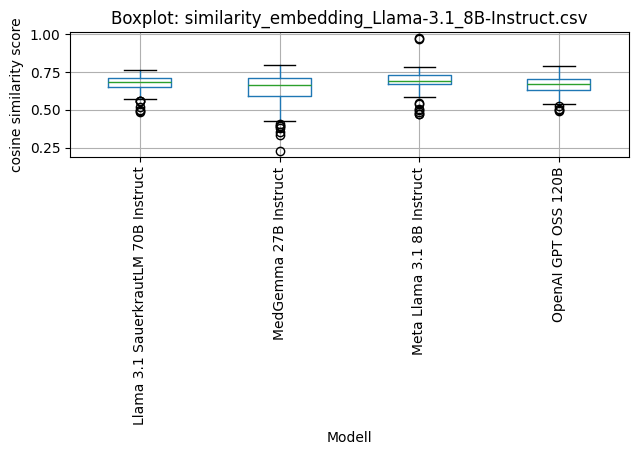

🔍 Verarbeite Datei: similarity_Alibaba-NLP_gte-multilingual-base.csv

📊 Statistik:
                                         mean       min       max       std
model_name                                                                 
Llama 3.1 SauerkrautLM 70B Instruct  0.817691  0.749349  0.895192  0.030326
MedGemma 27B Instruct                0.838942  0.737485  0.911549  0.037642
Meta Llama 3.1 8B Instruct           0.825440  0.715679  0.928599  0.040645
OpenAI GPT OSS 120B                  0.836942  0.734419  0.954096  0.037750




<Figure size 1200x600 with 0 Axes>

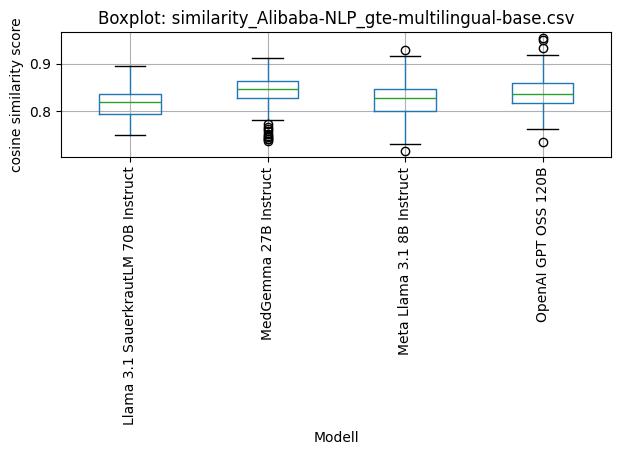

🔍 Verarbeite Datei: similarity_BAAI_bge-m3.csv

📊 Statistik:
                                         mean       min       max       std
model_name                                                                 
Llama 3.1 SauerkrautLM 70B Instruct  0.769068  0.672016  0.904910  0.040413
MedGemma 27B Instruct                0.838681  0.736359  0.917581  0.041977
Meta Llama 3.1 8B Instruct           0.805668  0.683697  0.942569  0.051620
OpenAI GPT OSS 120B                  0.853286  0.772873  0.913642  0.031596




<Figure size 1200x600 with 0 Axes>

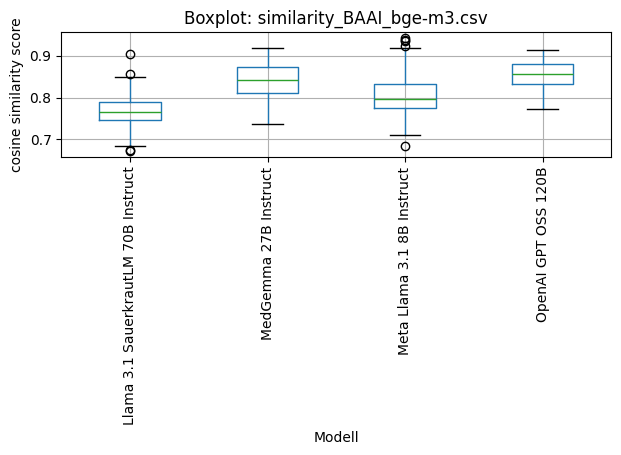

🔍 Verarbeite Datei: similarity_embedding_Jina_v3.csv

📊 Statistik:
                                         mean       min       max       std
model_name                                                                 
Llama 3.1 SauerkrautLM 70B Instruct  0.799833  0.685419  0.862930  0.034577
MedGemma 27B Instruct                0.825300  0.663748  0.900022  0.051461
Meta Llama 3.1 8B Instruct           0.830129  0.700027  0.941786  0.042229
OpenAI GPT OSS 120B                  0.831045  0.742582  0.876666  0.028638




<Figure size 1200x600 with 0 Axes>

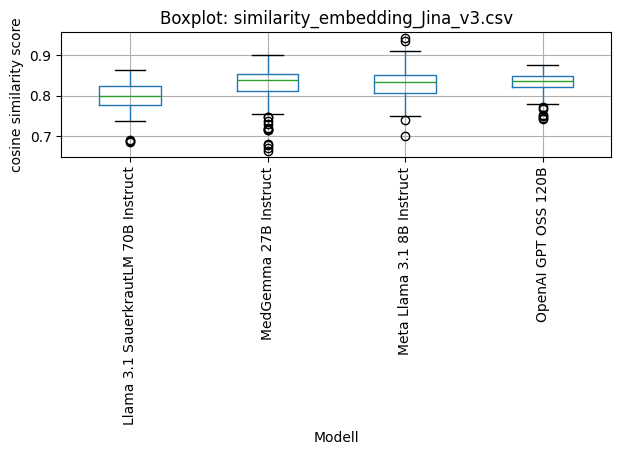

🔍 Verarbeite Datei: similarity_aari1995_German_Semantic_V3b.csv

📊 Statistik:
                                         mean       min       max       std
model_name                                                                 
Llama 3.1 SauerkrautLM 70B Instruct  0.923617  0.866118  0.978141  0.019780
MedGemma 27B Instruct                0.958984  0.901701  0.989503  0.016845
Meta Llama 3.1 8B Instruct           0.925447  0.644715  0.997732  0.039921
OpenAI GPT OSS 120B                  0.960181  0.913740  0.985678  0.013114




<Figure size 1200x600 with 0 Axes>

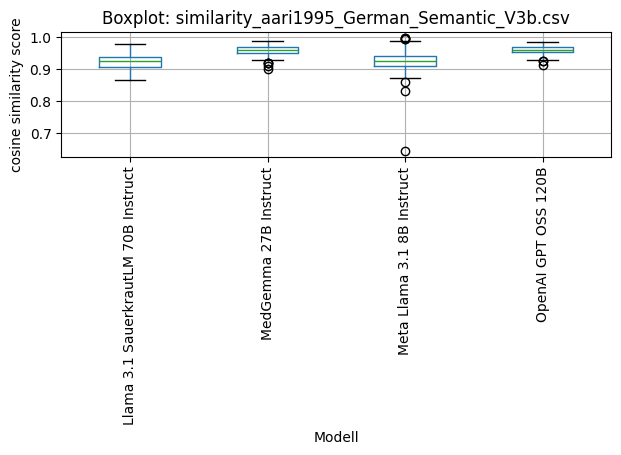

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Modelle, die ausgeschlossen werden sollen
exclude_models = ["OpenAI GPT-5", "GPT-5"]

# alle CSV-Dateien im Ordner "similarity_csv" finden
csv_files = glob.glob("similarity_csv/*.csv")

print("Gefundene Dateien:")
for f in csv_files:
    print(" -", os.path.basename(f))
print()

for file in csv_files:
    print(f"🔍 Verarbeite Datei: {os.path.basename(file)}\n")

    # CSV laden
    df = pd.read_csv(file)

    # Modelle herausfiltern
    df_filtered = df[~df["model_name"].isin(exclude_models)]

    # letzte Spalte = Similarity-Wert
    sim_col = df_filtered.columns[-1]

    # ---------------------------
    # Statistik berechnen
    # ---------------------------
    stats = df_filtered.groupby("model_name")[sim_col].agg(
        mean="mean",
        min="min",
        max="max",
        std="std"
    )

    print("📊 Statistik:")
    print(stats)
    print("\n")

    # ---------------------------
    # Boxplot erzeugen
    # ---------------------------
    plt.figure(figsize=(12,6))
    df_filtered.boxplot(column=sim_col, by="model_name")

    plt.title(f"Boxplot: {os.path.basename(file)}")
    plt.suptitle("")
    plt.xlabel("Modell")

    # ❗ feste Y-Achsen-Beschriftung
    plt.ylabel("cosine similarity score")

    # orthogonale Achsenbeschriftung
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()


Gefundene Dateien:
 - similarity_Alibaba-NLP_gte-multilingual-base.csv
 - similarity_BAAI_bge-m3.csv
 - similarity_aari1995_German_Semantic_V3b.csv
 - similarity_embedding_Jina_v3.csv
 - similarity_embedding_Llama-3.1_8B-Instruct.csv

Alle Plots wurden gespeichert in: similarity_all_plots_grid.png


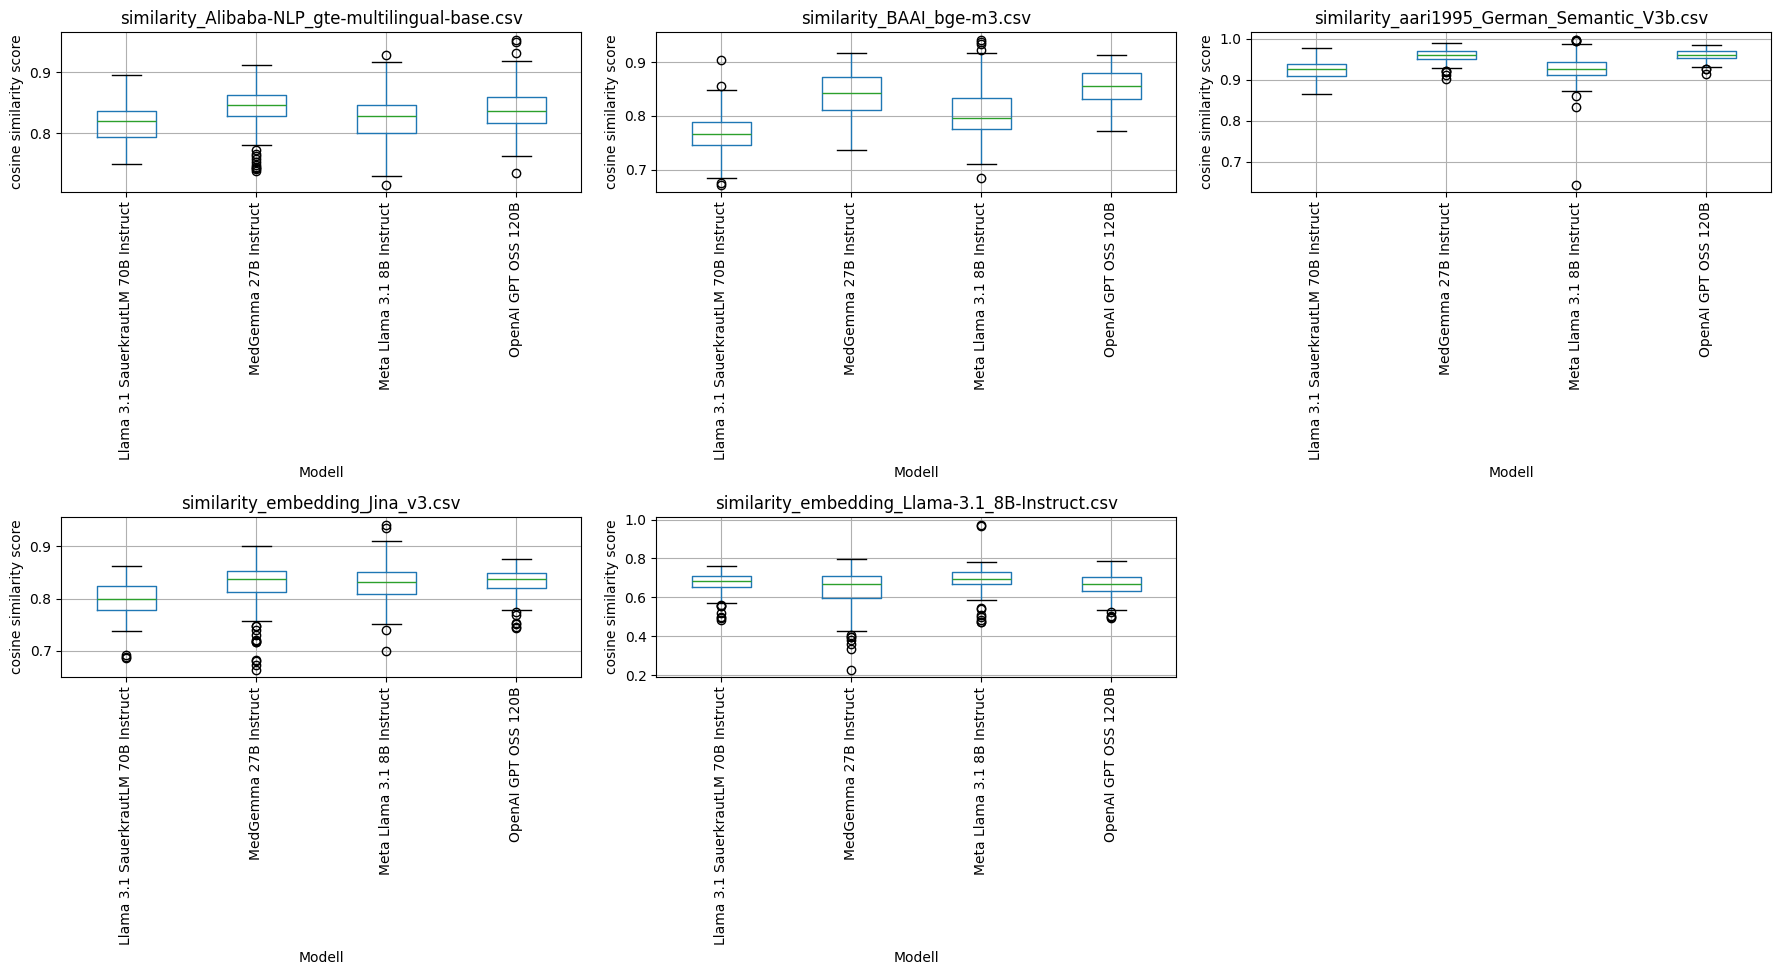

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Modelle, die ausgeschlossen werden sollen
exclude_models = ["OpenAI GPT-5", "GPT-5"]

# alle CSV-Dateien im Ordner "similarity_csv" finden
csv_files = glob.glob("similarity_csv/*.csv")

# sortieren für reproduzierbare Reihenfolge
csv_files = sorted(csv_files)

print("Gefundene Dateien:")
for f in csv_files:
    print(" -", os.path.basename(f))
print()

n_files = len(csv_files)
n_rows, n_cols = 2, 3  # Raster 2x3 (für 5 Plots ganz gut)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()  # 2D → 1D-Liste

for idx, file in enumerate(csv_files):
    ax = axes[idx]
    df = pd.read_csv(file)

    # Modelle herausfiltern
    df_filtered = df[~df["model_name"].isin(exclude_models)]

    # letzte Spalte = Similarity
    sim_col = df_filtered.columns[-1]

    # Boxplot in die jeweilige Achse zeichnen
    df_filtered.boxplot(column=sim_col, by="model_name", ax=ax)

    # Kürzerer Titel (nur Dateiname)
    ax.set_title(os.path.basename(file))
    ax.set_xlabel("Modell")
    ax.set_ylabel("cosine similarity score")

    # x-Ticks drehen
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# übrige leere Achsen (falls z.B. nur 5 Dateien) ausblenden
for j in range(n_files, len(axes)):
    axes[j].axis("off")

# globalen suptitle von pandas entfernen
plt.suptitle("")

plt.tight_layout()

output_filename = "similarity_all_plots_grid.png"
plt.savefig(output_filename, dpi=300)

print(f"Alle Plots wurden gespeichert in: {output_filename}")


## Boxplots für l2-distance

Gefundene Dateien:
 - l2_distance_aari1995_German_Semantic_V3b.csv
 - l2_distance_embedding_Llama-3.1_8B-Instruct.csv
 - l2_distance_embedding_Jina_v3.csv
 - l2_distance_BAAI_bge-m3.csv
 - l2_distance_Alibaba-NLP_gte-multilingual-base.csv

🔍 Verarbeite Datei: l2_distance_aari1995_German_Semantic_V3b.csv

📊 Statistik:
                                         mean       min       max       std
model_name                                                                 
Llama 3.1 SauerkrautLM 70B Instruct  0.387460  0.209088  0.517460  0.051632
MedGemma 27B Instruct                0.280483  0.144891  0.443395  0.058251
Meta Llama 3.1 8B Instruct           0.373000  0.067343  0.842953  0.100373
OpenAI GPT OSS 120B                  0.278504  0.169247  0.415355  0.045754




<Figure size 1200x600 with 0 Axes>

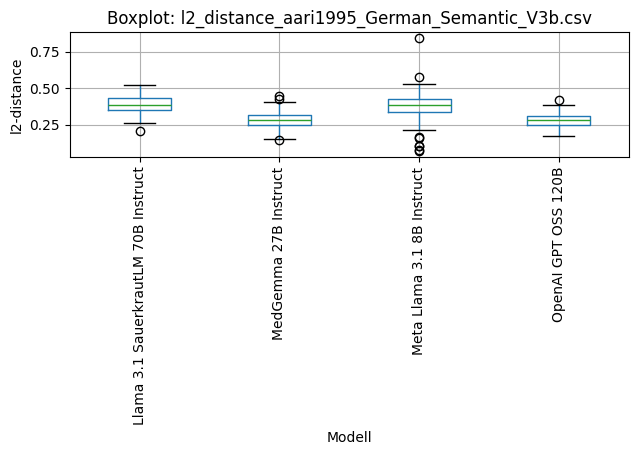

🔍 Verarbeite Datei: l2_distance_embedding_Llama-3.1_8B-Instruct.csv

📊 Statistik:
                                         mean       min       max       std
model_name                                                                 
Llama 3.1 SauerkrautLM 70B Instruct  0.805437  0.688632  1.015611  0.068874
MedGemma 27B Instruct                0.845996  0.637334  1.241988  0.123048
Meta Llama 3.1 8B Instruct           0.777759  0.228115  1.026636  0.107591
OpenAI GPT OSS 120B                  0.820213  0.652920  1.007046  0.068678




<Figure size 1200x600 with 0 Axes>

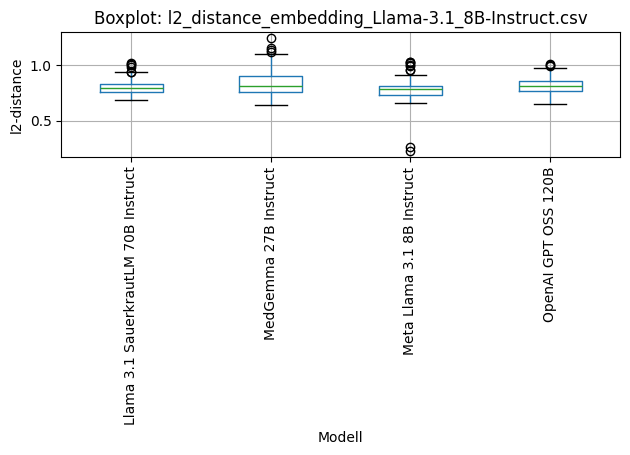

🔍 Verarbeite Datei: l2_distance_embedding_Jina_v3.csv

📊 Statistik:
                                         mean       min       max       std
model_name                                                                 
Llama 3.1 SauerkrautLM 70B Instruct  0.630696  0.523086  0.792587  0.053615
MedGemma 27B Instruct                0.585380  0.447274  0.819973  0.082087
Meta Llama 3.1 8B Instruct           0.578342  0.341115  0.776624  0.074825
OpenAI GPT OSS 120B                  0.579245  0.496928  0.717325  0.047680




<Figure size 1200x600 with 0 Axes>

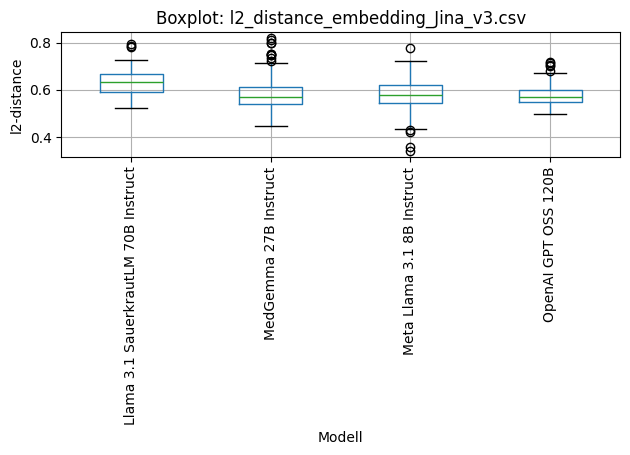

🔍 Verarbeite Datei: l2_distance_BAAI_bge-m3.csv

📊 Statistik:
                                         mean       min       max       std
model_name                                                                 
Llama 3.1 SauerkrautLM 70B Instruct  0.676842  0.436097  0.809918  0.061510
MedGemma 27B Instruct                0.563238  0.406002  0.726143  0.073856
Meta Llama 3.1 8B Instruct           0.617068  0.338912  0.795365  0.089265
OpenAI GPT OSS 120B                  0.538573  0.415590  0.673984  0.058310




<Figure size 1200x600 with 0 Axes>

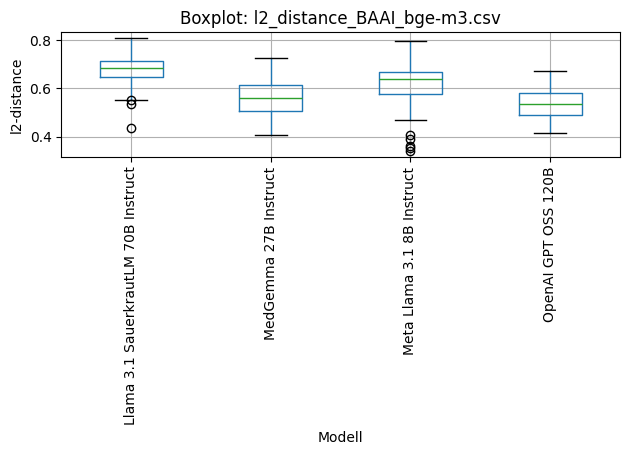

🔍 Verarbeite Datei: l2_distance_Alibaba-NLP_gte-multilingual-base.csv

📊 Statistik:
                                         mean       min       max       std
model_name                                                                 
Llama 3.1 SauerkrautLM 70B Instruct  0.601717  0.457839  0.708026  0.050781
MedGemma 27B Instruct                0.563973  0.420597  0.724590  0.063949
Meta Llama 3.1 8B Instruct           0.586652  0.377892  0.754084  0.070760
OpenAI GPT OSS 120B                  0.566712  0.302999  0.728808  0.070717




<Figure size 1200x600 with 0 Axes>

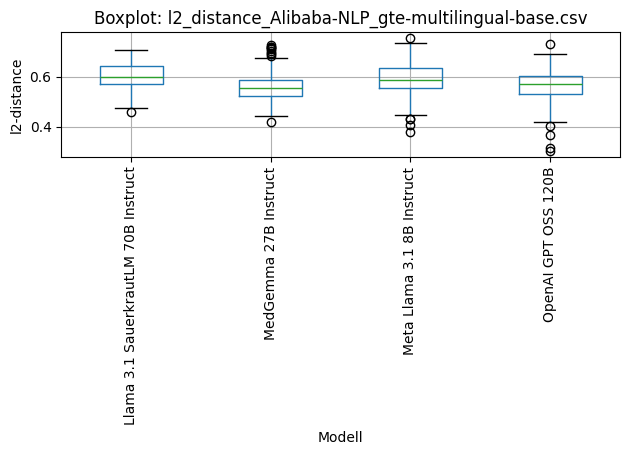

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Modelle, die ausgeschlossen werden sollen
exclude_models = ["OpenAI GPT-5", "GPT-5"]

# alle CSV-Dateien im Ordner "l2_distance" finden
csv_files = glob.glob("l2_distance/*.csv")

print("Gefundene Dateien:")
for f in csv_files:
    print(" -", os.path.basename(f))
print()

for file in csv_files:
    print(f"🔍 Verarbeite Datei: {os.path.basename(file)}\n")

    # CSV laden
    df = pd.read_csv(file)

    # Modelle herausfiltern
    df_filtered = df[~df["model_name"].isin(exclude_models)]

    # letzte Spalte = distance
    dist_col = df_filtered.columns[-1]

    # ---------------------------
    # Statistik berechnen
    # ---------------------------
    stats = df_filtered.groupby("model_name")[dist_col].agg(
        mean="mean",
        min="min",
        max="max",
        std="std"
    )

    print("📊 Statistik:")
    print(stats)
    print("\n")

    # ---------------------------
    # Boxplot erzeugen
    # ---------------------------
    plt.figure(figsize=(12,6))
    df_filtered.boxplot(column=dist_col, by="model_name")

    plt.title(f"Boxplot: {os.path.basename(file)}")
    plt.suptitle("")
    plt.xlabel("Modell")

    # ❗ feste Y-Achsen-Bezeichnung
    plt.ylabel("l2-distance")

    # orthogonale Achsenbeschriftung
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()


## Alle Zusammen in eine Plot für similarity

Gefundene Dateien:
 - similarity_Alibaba-NLP_gte-multilingual-base.csv
 - similarity_BAAI_bge-m3.csv
 - similarity_aari1995_German_Semantic_V3b.csv
 - similarity_embedding_Jina_v3.csv
 - similarity_embedding_Llama-3.1_8B-Instruct.csv

Gespeichert als: similarity_all_plots_3x2.png


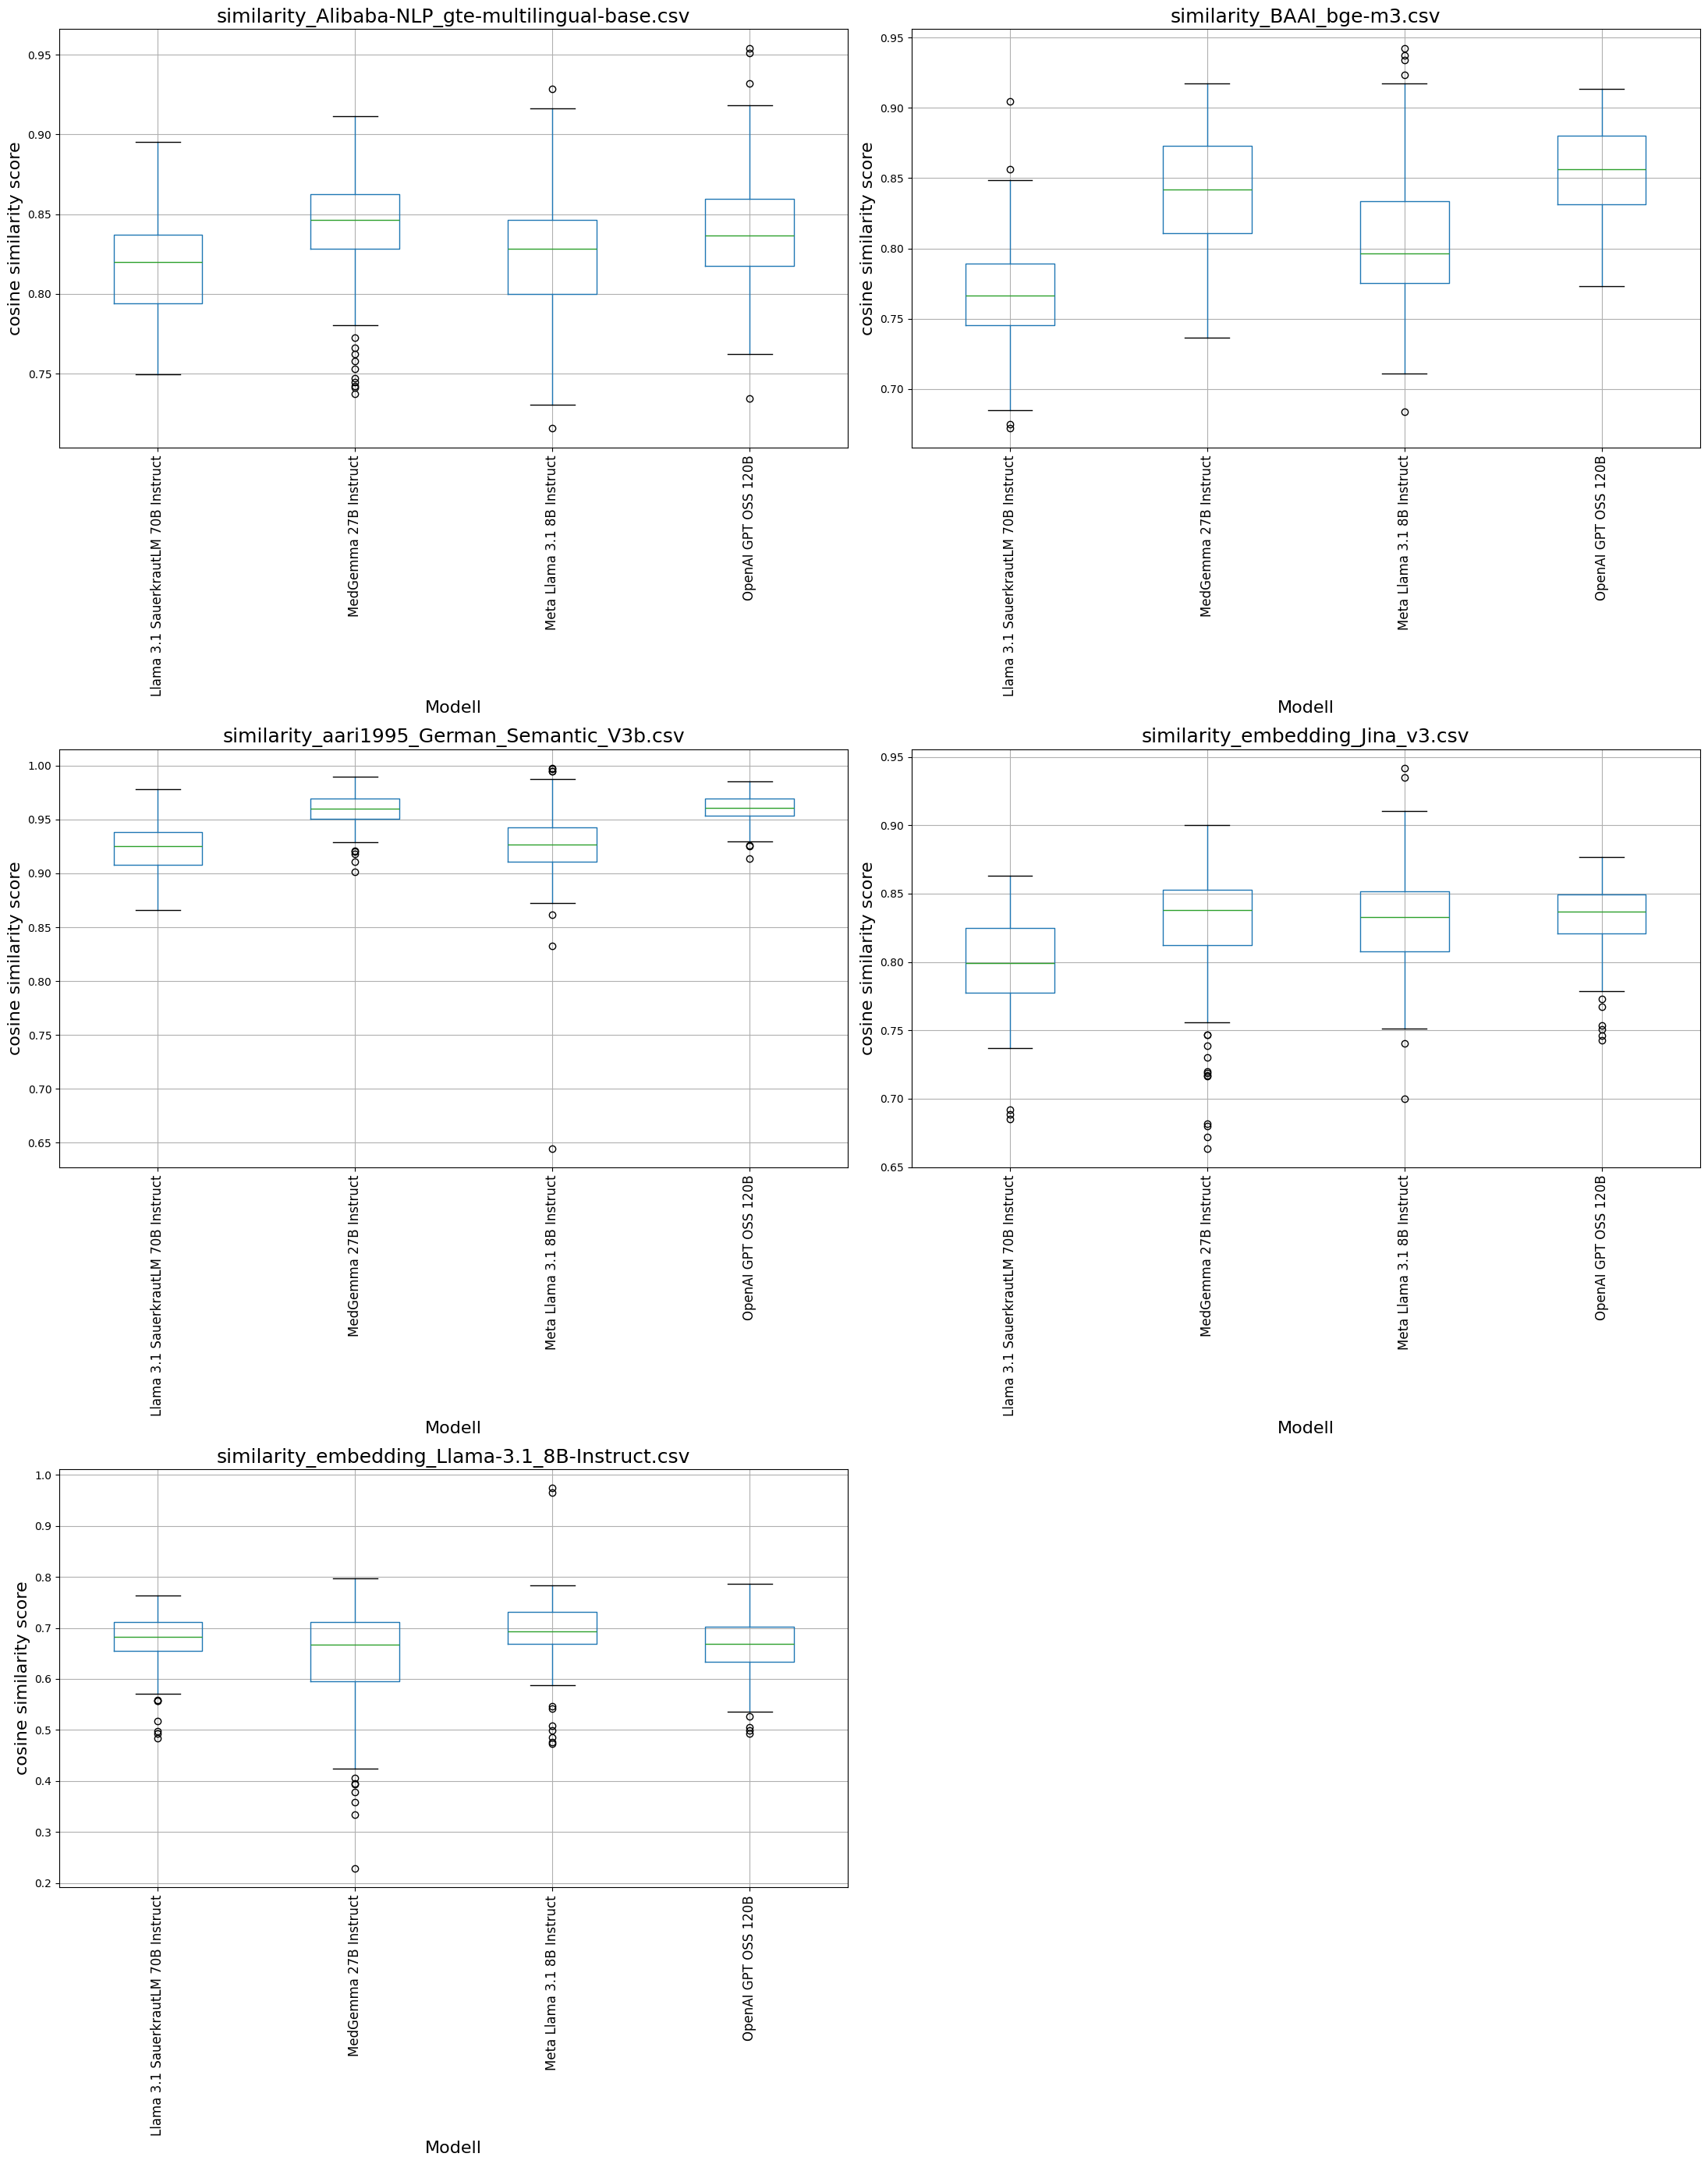

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Modelle, die ausgeschlossen werden sollen
exclude_models = ["OpenAI GPT-5", "GPT-5"]

# alle CSV-Dateien im Ordner "similarity_csv" finden
csv_files = glob.glob("similarity_csv/*.csv")
csv_files = sorted(csv_files)

print("Gefundene Dateien:")
for f in csv_files:
    print(" -", os.path.basename(f))
print()

n_files = len(csv_files)

# 3 Zeilen × 2 Spalten
n_rows, n_cols = 3, 2

# große Figur für LaTeX
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 28))
axes = axes.flatten()

for idx, file in enumerate(csv_files):
    ax = axes[idx]
    df = pd.read_csv(file)

    # GPT-5 Modelle herausfiltern
    df_filtered = df[~df["model_name"].isin(exclude_models)]

    # letzte Spalte = Similarity
    sim_col = df_filtered.columns[-1]

    # Boxplot
    df_filtered.boxplot(column=sim_col, by="model_name", ax=ax)

    ax.set_title(os.path.basename(file), fontsize=18)
    ax.set_xlabel("Modell", fontsize=16)
    ax.set_ylabel("cosine similarity score", fontsize=16)

    # gedrehte x-Achse Labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)

# nicht benötigte Achsen ausblenden (falls weniger als 6 Dateien)
for j in range(n_files, len(axes)):
    axes[j].axis("off")

plt.suptitle("")
plt.tight_layout()

output_filename = "similarity_all_plots_3x2.png"
plt.savefig(output_filename, dpi=300)

print(f"Gespeichert als: {output_filename}")


## Alle zusammen in einem Plot für L2-distanz

Gefundene Dateien:
 - l2_distance_Alibaba-NLP_gte-multilingual-base.csv
 - l2_distance_BAAI_bge-m3.csv
 - l2_distance_aari1995_German_Semantic_V3b.csv
 - l2_distance_embedding_Jina_v3.csv
 - l2_distance_embedding_Llama-3.1_8B-Instruct.csv

Gespeichert als: l2_distance_all_plots_3x2.png


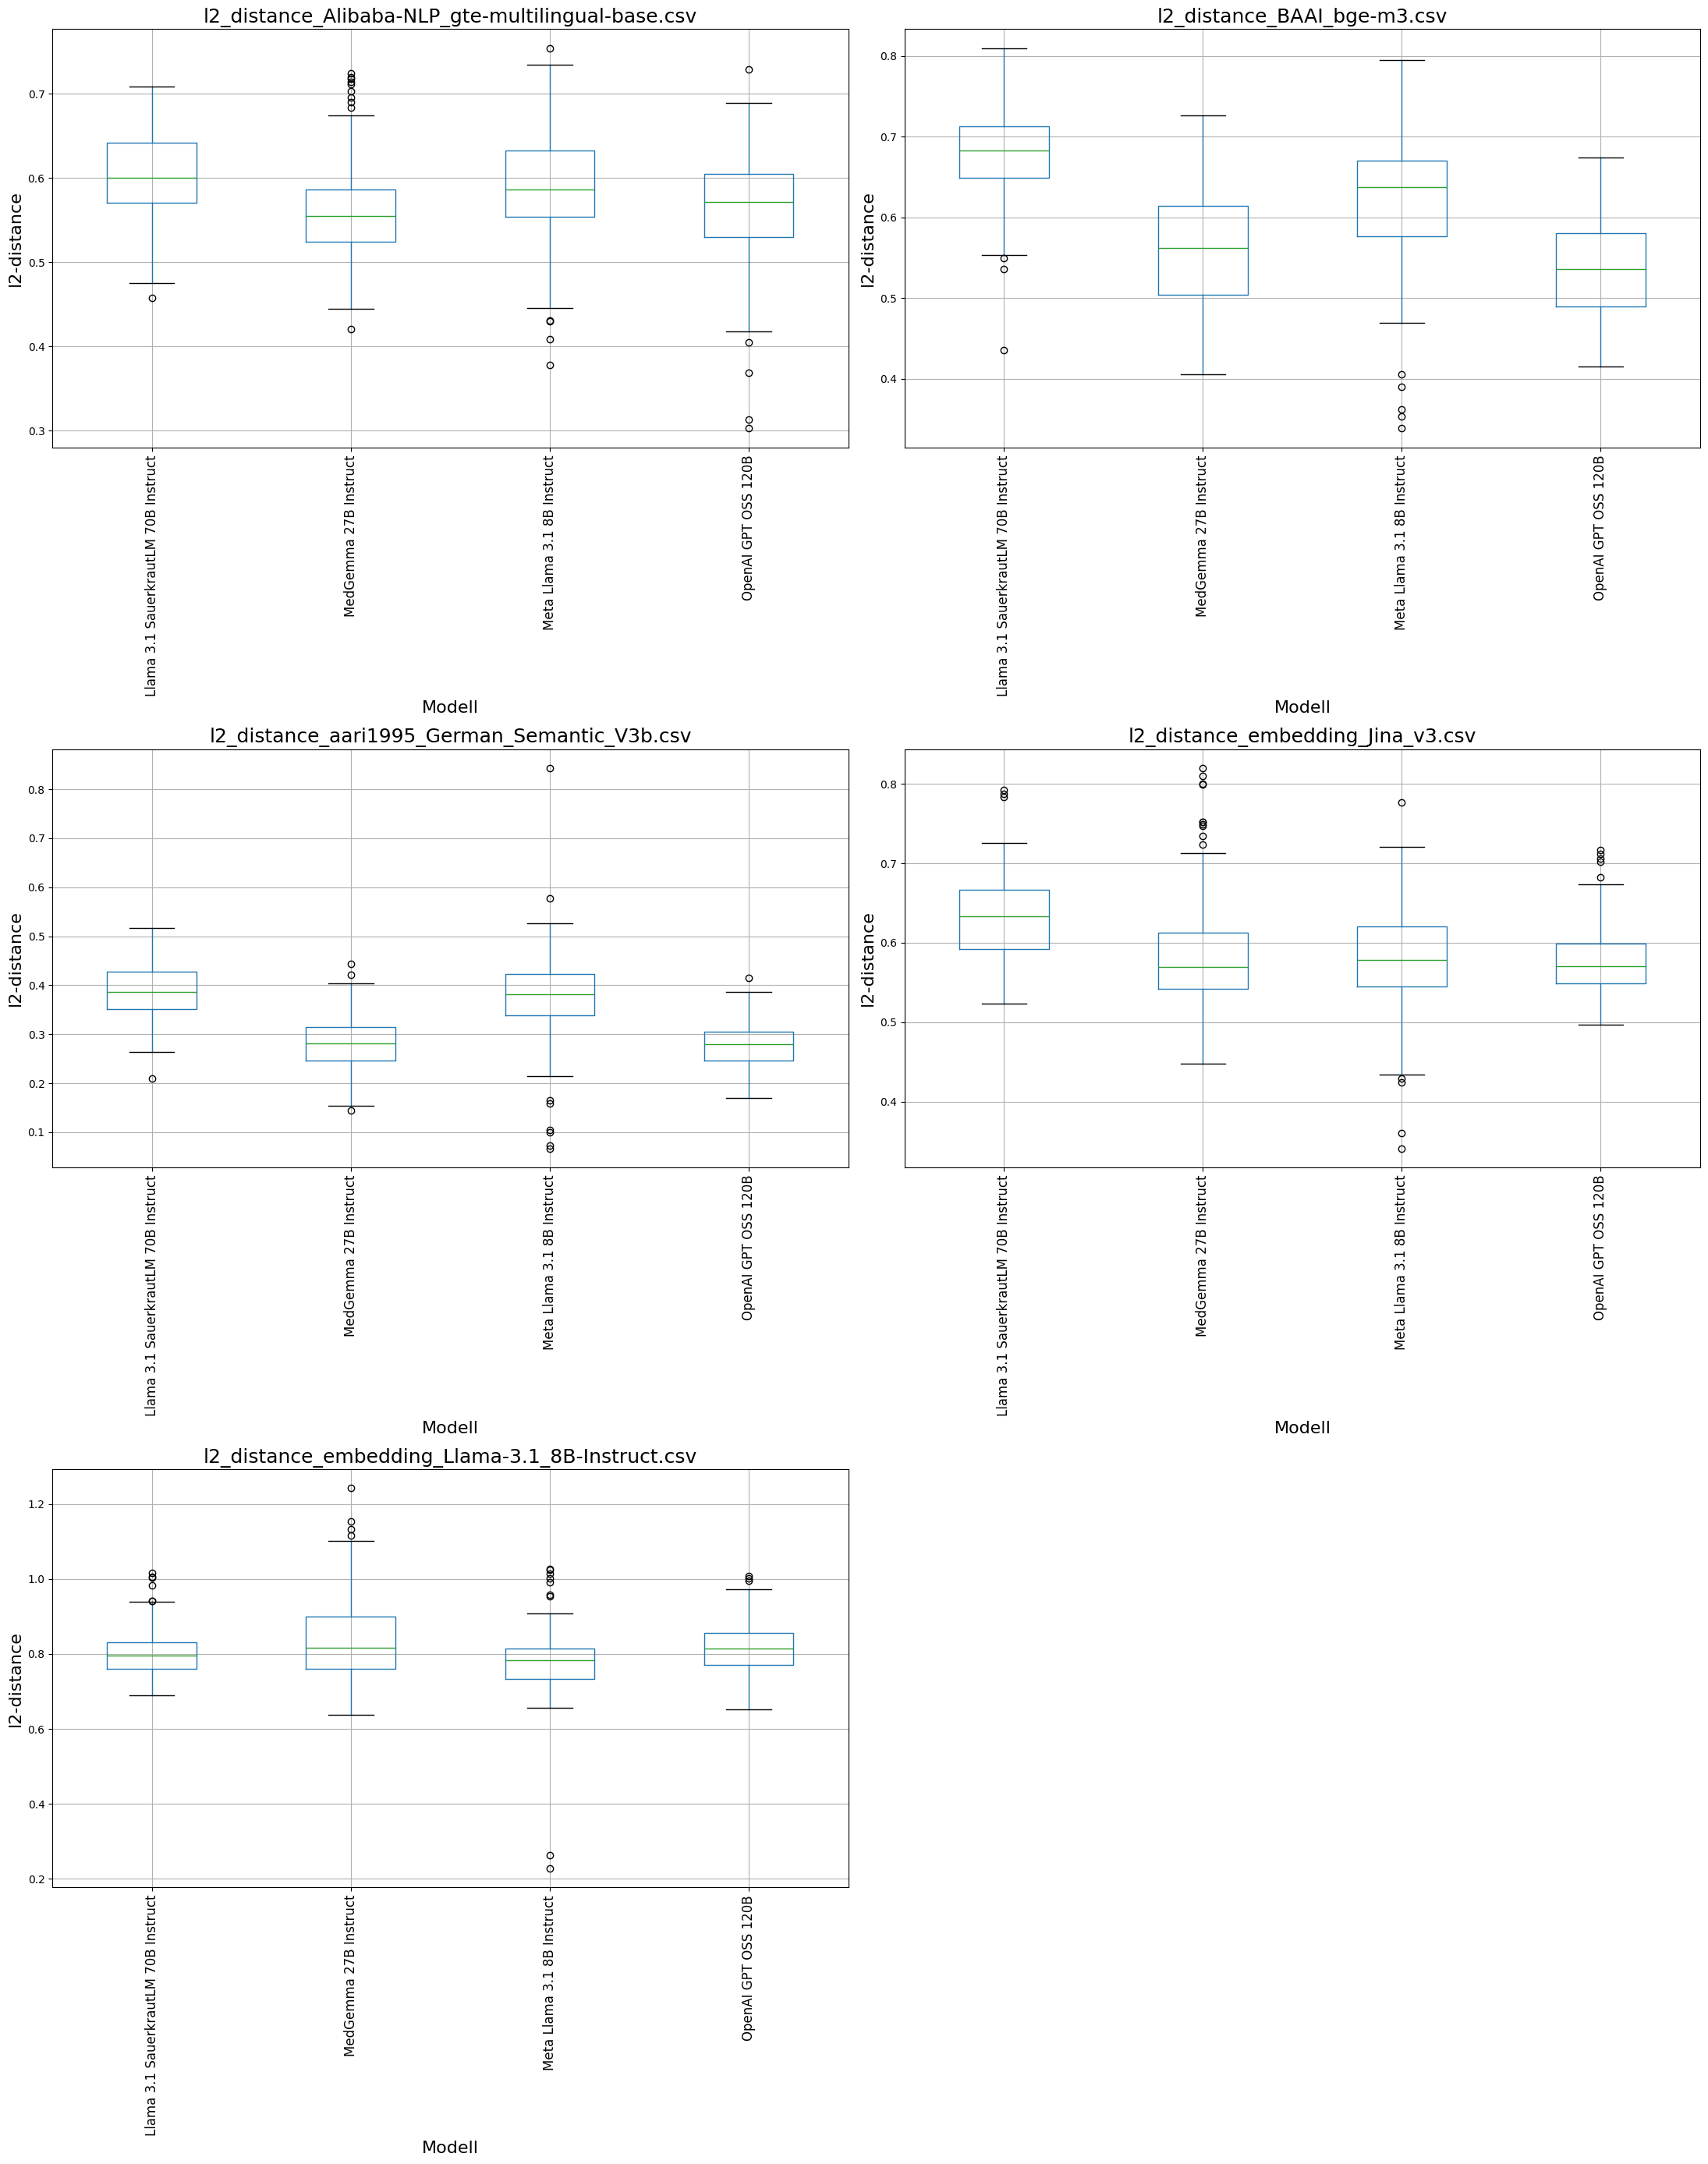

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Modelle, die ausgeschlossen werden sollen
exclude_models = ["OpenAI GPT-5", "GPT-5"]

# alle CSV-Dateien im Ordner "l2_distance" finden
csv_files = glob.glob("l2_distance/*.csv")
csv_files = sorted(csv_files)

print("Gefundene Dateien:")
for f in csv_files:
    print(" -", os.path.basename(f))
print()

n_files = len(csv_files)

# 3 Reihen × 2 Spalten (vertikal: 1-2 / 3-4 / 5-6)
n_rows, n_cols = 3, 2

# große Figure für LaTeX
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 28))
axes = axes.flatten()

for idx, file in enumerate(csv_files):
    ax = axes[idx]
    df = pd.read_csv(file)

    # GPT-5 Modelle herausfiltern
    df_filtered = df[~df["model_name"].isin(exclude_models)]

    # letzte Spalte = L2-distance
    dist_col = df_filtered.columns[-1]

    # Boxplot
    df_filtered.boxplot(column=dist_col, by="model_name", ax=ax)

    # Titel + Achsenbeschriftung
    ax.set_title(os.path.basename(file), fontsize=18)
    ax.set_xlabel("Modell", fontsize=16)
    ax.set_ylabel("l2-distance", fontsize=16)

    # X-Achsenlabels drehen
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)

# unbenutzte Achsen deaktivieren (falls weniger als 6 CSVs)
for j in range(n_files, len(axes)):
    axes[j].axis("off")

plt.suptitle("")
plt.tight_layout()

output_filename = "l2_distance_all_plots_3x2.png"
plt.savefig(output_filename, dpi=300)

print(f"Gespeichert als: {output_filename}")


# NLI aber Tokensbegrezung 512?!!!

In [19]:
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


# -------------------------------------------------------
# 0. NLI-Modell laden (Deutsch/Multilingual)
# -------------------------------------------------------
nli_model_name = "joeddav/xlm-roberta-large-xnli"
tokenizer_nli = AutoTokenizer.from_pretrained(nli_model_name)
model_nli = AutoModelForSequenceClassification.from_pretrained(nli_model_name)
model_nli.eval()


# -------------------------------------------------------
# 1. NLI-Hilfsfunktion
# -------------------------------------------------------
def nli_predict(premise, hypothesis):
    if not isinstance(premise, str) or not isinstance(hypothesis, str):
        return {"entailment": np.nan, "neutral": np.nan, "contradiction": np.nan, "label": None}

    inputs = tokenizer_nli(
        premise,
        hypothesis,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        logits = model_nli(**inputs).logits

    probs = torch.softmax(logits, dim=1).numpy()[0]

    # Reihenfolge: 0=contradiction, 1=neutral, 2=entailment
    labels = ["contradiction", "neutral", "entailment"]
    best_label = labels[int(probs.argmax())]

    return {
        "entailment": float(probs[2]),
        "neutral": float(probs[1]),
        "contradiction": float(probs[0]),
        "label": best_label
    }


# -------------------------------------------------------
# 2. Join df1 + df2 über audio_id
# -------------------------------------------------------

# WICHTIG: df1["text"] = LLM-Output / Summary
#          df2["text"] = STT-Transcript

df_join = df1.merge(
    df2[["audio_id", "text"]].rename(columns={"text": "transcript_text"}),
    on="audio_id",
    suffixes=("_df1", "_df2")
)

# summary_text aus df1 holen
df_join = df_join.rename(columns={"text": "summary_text"})


# -------------------------------------------------------
# 3. NLI pro Zeile berechnen
# -------------------------------------------------------
nli_rows = []

for idx, row in df_join.iterrows():
    transcript = row["transcript_text"]   # STT
    summary = row["summary_text"]         # LLM Output

    res = nli_predict(transcript, summary)

    nli_rows.append({
        "experiment_id": row["experiment_id"],
        "audio_id": row["audio_id"],
        "model_name": row["model_name"],
        "entailment": res["entailment"],
        "neutral": res["neutral"],
        "contradiction": res["contradiction"],
        "nli_label": res["label"]
    })


df_nli = pd.DataFrame(nli_rows)

print("\n===== NLI Ergebnisse (erste Zeilen) =====")
display(df_nli.head())


# -------------------------------------------------------
# 4. Aggregation pro Modell
# -------------------------------------------------------
nli_summary = (
    df_nli
    .groupby("model_name")[["entailment", "neutral", "contradiction"]]
    .mean()
    .reset_index()
)

# Halluzinations-Score = neutral + contradiction
nli_summary["hallucination_score"] = (
    nli_summary["neutral"] + nli_summary["contradiction"]
)

print("\n===== NLI Summary =====")
display(nli_summary)


# -------------------------------------------------------
# 5. CSV Export
# -------------------------------------------------------
df_nli.to_csv("nli_per_sample.csv", index=False, encoding="utf-8")
print("✔ CSV gespeichert: nli_per_sample.csv")

nli_summary.to_csv("nli_summary_per_model.csv", index=False, encoding="utf-8")
print("✔ CSV gespeichert: nli_summary_per_model.csv")


Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



===== NLI Ergebnisse (erste Zeilen) =====


,experiment_id,audio_id,model_name,entailment,neutral,contradiction,nli_label
0,1765,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.050936,0.948667,0.000398,neutral
1,1762,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.057694,0.941855,0.000451,neutral
2,1767,Anam_Beinschmerzen,MedGemma 27B Instruct,0.040066,0.958271,0.001664,neutral
3,1766,Anam_Beinschmerzen,Llama 3.1 SauerkrautLM 70B Instruct,0.983291,0.016009,0.000700,entailment
4,1769,Anam_Beinschmerzen,MedGemma 27B Instruct,0.046112,0.952346,0.001543,neutral



===== NLI Summary =====


,model_name,entailment,neutral,contradiction,hallucination_score
0,GPT-5,0.524489,0.436730,0.038781,0.475511
1,Llama 3.1 SauerkrautLM 70B Instruct,0.236810,0.724957,0.038233,0.763190
2,MedGemma 27B Instruct,0.394012,0.516621,0.089367,0.605988
3,Meta Llama 3.1 8B Instruct,0.263265,0.682635,0.054100,0.736735
4,OpenAI GPT OSS 120B,0.567878,0.383823,0.048299,0.432122
5,OpenAI GPT-5,0.468073,0.501494,0.030433,0.531927


✔ CSV gespeichert: nli_per_sample.csv
✔ CSV gespeichert: nli_summary_per_model.csv
